# Analiza e të Dhënave të Krimit – Los Angeles (2020 deri tani)

## Përshkrim i Projektit
Ky notebook analizon dataset-in e krimeve të raportuara nga Departamenti i Policisë së Los Angeles (LAPD) nga viti 2020 deri në ditët e sotme.  
Dataset-i përmban mbi **1 milion rekorde** dhe **28 kolona**, duke mbuluar informacione si: lloji i krimit, zona, koha, viktimat, armët e përdorura dhe statusi i çështjes.

**Burimi:** [Los Angeles Open Data Portal](https://data.lacity.org/)

---

## 1. Importimi i Librarive

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display all columns without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print('Librarite u importuan me sukses.')

Librarite u importuan me sukses.


## 2. Ngarkimi i Dataset-it

In [2]:
# Ngarkojmë dataset-in
FILE_PATH = 'Crime_Data_from_2020_to_Present.csv'

df = pd.read_csv(FILE_PATH, low_memory=False)

print(f'Dimensionet e dataset-it: {df.shape}')
print(f'Numri i kolonave: {df.shape[1]}')
print(f'Numri i rekordeve: {df.shape[0]:,}')
df.head(3)

Dimensionet e dataset-it: (1005198, 28)
Numri i kolonave: 28
Numri i rekordeve: 1,005,198


,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,NaN,0,M,O,101.0,STREET,NaN,NaN,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,47,M,O,128.0,BUS STOP/LAYOVER (ALSO QUERY 124),NaN,NaN,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,0344 1251,19,X,X,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002


## 3. Të dhënat kryesore mbi datasetin

In [3]:
# Tipet e të dhënave
print('=== Tipet e kolonave ===')
print(df.dtypes)
print()

# Statistika përshkruese për kolonat numerike
print('=== Statistika Përshkruese ===')
df[['Vict Age', 'TIME OCC']].describe()

=== Tipet e kolonave ===
DR_NO               int64
Date Rptd             str
DATE OCC              str
TIME OCC            int64
AREA                int64
AREA NAME             str
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc           str
Mocodes               str
Vict Age            int64
Vict Sex              str
Vict Descent          str
Premis Cd         float64
Premis Desc           str
Weapon Used Cd    float64
Weapon Desc           str
Status                str
Status Desc           str
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION              str
Cross Street          str
LAT               float64
LON               float64
dtype: object

=== Statistika Përshkruese ===


,Vict Age,TIME OCC
count,1.005198e+06,1.005198e+06
mean,2.891253e+01,1.339911e+03
std,2.199382e+01,6.510531e+02
min,-4.000000e+00,1.000000e+00
25%,0.000000e+00,9.000000e+02
50%,3.000000e+01,1.420000e+03
75%,4.400000e+01,1.900000e+03
max,1.200000e+02,2.359000e+03


In [4]:
# Vlerat munguese për çdo kolonë
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Vlera Mungese': missing,
    'Përqindja (%)': missing_pct
}).query('`Vlera Mungese` > 0').sort_values('Përqindja (%)', ascending=False)

print('=== Kolonat me vlera mungese ===')
print(missing_df)


for col in df.columns:
    print(f"\nColumn {col} has {df[col].isnull().sum()} null values")

=== Kolonat me vlera mungese ===
                Vlera Mungese  Përqindja (%)
Crm Cd 4              1005134          99.99
Crm Cd 3              1002884          99.77
Crm Cd 2               936039          93.12
Cross Street           850955          84.66
Weapon Desc            677918          67.44
Weapon Used Cd         677918          67.44
Mocodes                151760          15.10
Vict Descent           144794          14.40
Vict Sex               144782          14.40
Premis Desc               588           0.06
Premis Cd                  16           0.00
Crm Cd 1                   11           0.00
Status                      1           0.00

Column DR_NO has 0 null values

Column Date Rptd has 0 null values

Column DATE OCC has 0 null values

Column TIME OCC has 0 null values

Column AREA has 0 null values

Column AREA NAME has 0 null values

Column Rpt Dist No has 0 null values

Column Part 1-2 has 0 null values

Column Crm Cd has 0 null values

Column Crm Cd Desc has 0 

## Sqarim për Emrat e Kolonave

| Kolona | Përshkrim |
|--------|-----------|
| DR_NO | Unique identifier for the crime report |
| Date Rptd | The date the crime was reported |
| DATE OCC | The actual date the crime occurred |
| TIME OCC | The time the crime occurred, usually in 24-hour format |
| AREA | Numeric code representing the geographical area where the crime occurred |
| AREA NAME | Name of the geographical area |
| Rpt Dist No | Reporting district number for the incident |
| Part 1-2 | Crime classification (e.g., Part 1 for serious crimes, Part 2 for less serious crimes) |
| Crm Cd | Numeric code representing the type of crime |
| Crm Cd Desc | Description of the crime type |
| Mocodes | Modus operandi codes, describing the method used in the crime |
| Vict Age | Age of the victim |
| Vict Sex | Gender of the victim (e.g., Male, Female, Unknown) |
| Vict Descent | Ethnicity or descent of the victim |
| Premis Cd | Numeric code for the type of premises where the crime occurred |
| Premis Desc | Description of the type of premises (e.g., residence, vehicle, commercial) |
| Weapon Used Cd | Numeric code for the weapon used in the crime, if applicable |
| Weapon Desc | Description of the weapon used |
| Status | Status code of the crime case (e.g., Open, Solved) |
| Status Desc | Description of the case status |
| Crm Cd 1 | Additional crime codes, if the incident involved multiple offenses |
| Crm Cd 2 | Additional crime codes, if the incident involved multiple offenses |
| Crm Cd 3 | Additional crime codes, if the incident involved multiple offenses |
| Crm Cd 4 | Additional crime codes, if the incident involved multiple offenses |
| LOCATION | Text description of the crime location |
| Cross Street | Nearby cross street for the crime location |
| LAT | Latitude of the crime location |
| LON | Longitude of the crime location |

## 4. Pastrimi i të Dhënave dhe Vendimmarrja për Vlerat Munguese

### Strategjia:
| Kolona | Vlera Mungese | Vendimi | Arsyeja |
|---|---|---|---|
| `Weapon Used Cd` / `Weapon Desc` | ~67% | Zëvendëso me `'UNKNOWN'` / `0` | Mungesa tregon krim pa armë |
| `Vict Sex` / `Vict Descent` | ~14% | Zëvendëso me `'X'` (E panjohur) | Kodi zyrtar i LAPD-së |
| `Mocodes` | ~15% | Zëvendëso me `'NONE'` | Kode shtesë opsionale |
| `Crm Cd 2/3/4` | >93% | Mbaj si NaN / shpërnore | Kolona sekondare, jo kyçe |
| `Cross Street` | ~85% | Mbaj si NaN | Jo e nevojshme për analiza |
| `Premis Desc` / `Premis Cd` / `Crm Cd 1` / `Status` | <0.1% | Zëvendëso me `'UNKNOWN'` | Shumë pak mungesa |

In [5]:
# --- Konvertimi i datave ---
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], format='%m/%d/%Y %H:%M', errors='coerce')
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], format='%m/%d/%Y %H:%M', errors='coerce')

# Nxjerrja e veçorive kohore
df['Year']  = df['DATE OCC'].dt.year
df['Month'] = df['DATE OCC'].dt.month
df['Hour']  = (df['TIME OCC'] // 100)  # TIME OCC format: HHMM
df['DayOfWeek'] = df['DATE OCC'].dt.day_name()

# --- Pastrimi i kolonave kategorike ---
df['Weapon Desc']   = df['Weapon Desc'].fillna('UNKNOWN')
df['Weapon Used Cd']= df['Weapon Used Cd'].fillna(0)
df['Vict Sex']      = df['Vict Sex'].fillna('X').replace({'': 'X', '-': 'X'})
df['Vict Descent']  = df['Vict Descent'].fillna('X').replace({'': 'X', '-': 'X'})
df['Mocodes']       = df['Mocodes'].fillna('NONE')
df['Premis Desc']   = df['Premis Desc'].fillna('UNKNOWN')

# --- Pastrimi i moshës (vlera negative ose jashtë intervalit logjik) ---
df['Vict Age'] = df['Vict Age'].replace(0, np.nan)  # 0 = e panjohur
df.loc[df['Vict Age'] < 0, 'Vict Age'] = np.nan
df.loc[df['Vict Age'] > 99, 'Vict Age'] = np.nan

# --- Kolona ndihmëse: ka armë apo jo ---
df['Has Weapon'] = (df['Weapon Desc'] != 'UNKNOWN').astype(int)

# --- Kolona: rast i zgjidhur apo jo ---
df['Solved'] = df['Status Desc'].isin(['Adult Arrest', 'Juv Arrest']).astype(int)

print(f'Dataset pas pastrimit: {df.shape}')
print(f'Vlera NaN në Vict Age pas pastrimit: {df["Vict Age"].isnull().sum():,}')
print('Pastrimi u krye me sukses!')

Dataset pas pastrimit: (1005198, 34)
Vlera NaN në Vict Age pas pastrimit: 269,514
Pastrimi u krye me sukses!


In [6]:
# Ruajtja e dataset-it të pastruar (master dataset)
df.to_csv('Crime_Data_Filtered.csv', index=False)
print("Crime_Data_Filtered.csv u ruajt me sukses.")

Crime_Data_Filtered.csv u ruajt me sukses.


## Pyetja 1: A viktimizohet ndonjë grup etnik më shumë se pritshmëria? 

**Pyetja:** Cilat grupe etnike kanë Indeks Viktimizimi (IV) mbi 1, që tregon mbi‑viktimizim relativ ndaj përqindjes së tyre në popullsi?

<small>Ky seksion llogarit `victim_pct` nga subset-i `df_known`, bashkon me `pop_pct` (Census 2020) dhe kalkulon `IV = % Viktima / % Popullsia`. Grafiku barh horizontale vizaton këto IV dhe thekson me ngjyra vlerat e larta (p.sh. IV > 1.2). Pra pyetja e përgjigjet duke treguar grupet me `IV > 1`.</small>

In [7]:
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# --- Mapa e prejardhjes ---
descent_map = {
    'H': 'Hispanic/Latino',
    'W': 'White',
    'B': 'Black/Afr.Am.',
    'A': 'Other Asian',
    'O': 'Other',
    'K': 'Korean',
    'F': 'Filipino',
    'C': 'Chinese',
    'J': 'Japanese',
    'V': 'Vietnamese',
    'I': 'Am. Indian',
    'Z': 'Asian Indian',
    'P': 'Pacific Islander',
    'X': 'Unknown'
}

# Popullsia e LA sipas Census 2020 (%)
# Burimi: U.S. Census Bureau, 2020 Decennial Census, Los Angeles City
pop_pct = {
    'Hispanic/Latino':  47.7,
    'White':            27.8,
    'Black/Afr.Am.':     8.3,
    'Other Asian':       2.0,   # agregim i disa kategorive Aziatike
    'Other':             4.2,
    'Korean':            1.0,
    'Chinese':           1.5,
    'Filipino':          0.8,
    'Vietnamese':        0.5,
    'Am. Indian':        0.2,
    'Pacific Islander':  0.3,
    'Asian Indian':      0.9,
}

df['Descent Name'] = df['Vict Descent'].map(descent_map)
print(f'Dataset i ngarkuar: {df.shape[0]:,} rekorde')
print('Pastrimi dhe mapimi u kryen me sukses.')

Dataset i ngarkuar: 1,005,198 rekorde
Pastrimi dhe mapimi u kryen me sukses.


---
## Grafiku 1 — Indeksi i Viktimizimit: Krime të Gjitha vs Popullsia

**Ky grafik tregon:** Sa herë më shumë viktimizohet çdo grup etnik krahasuar me pjesën e tij në popullsi.
**IV = 1.0** = proporcional me popullsinë | **IV > 1.0** = mbi-viktimizim | **IV < 1.0** = nën-viktimizim

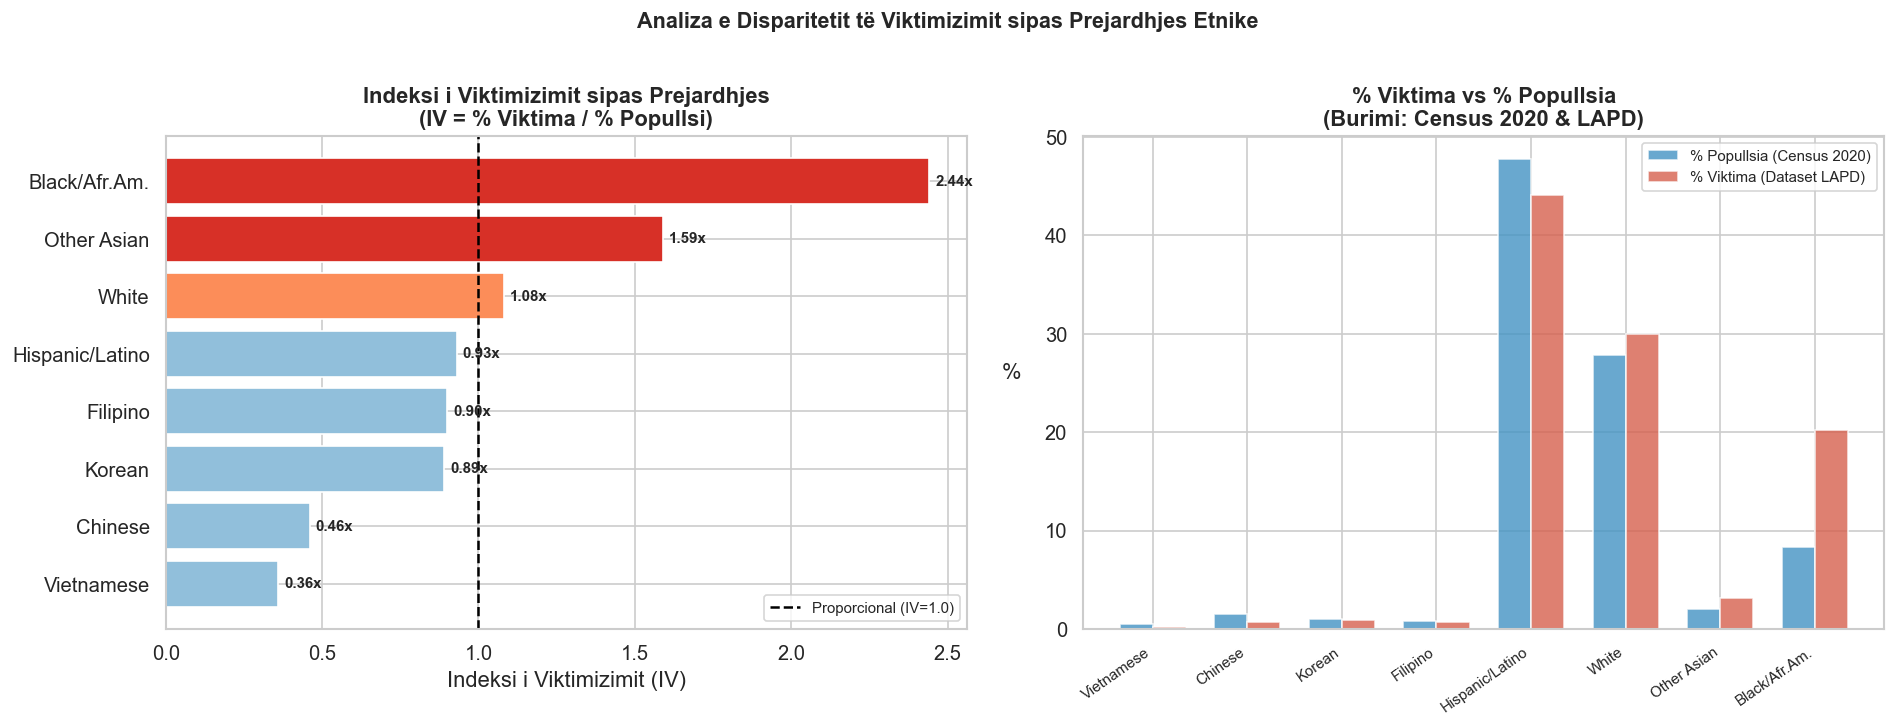


=== Indeksi i Viktimizimit ===
          Grupi  Popullsia_%  Viktima_%   IV
  Black/Afr.Am.          8.3  20.220602 2.44
    Other Asian          2.0   3.176985 1.59
          White         27.8  29.990948 1.08
Hispanic/Latino         47.7  44.131957 0.93
       Filipino          0.8   0.720256 0.90
         Korean          1.0   0.891908 0.89
        Chinese          1.5   0.689439 0.46
     Vietnamese          0.5   0.177905 0.36


In [8]:
# Llogaritja e Indeksit të Viktimizimit (IV)
main_groups = ['Hispanic/Latino', 'White', 'Black/Afr.Am.', 'Other Asian',
               'Korean', 'Filipino', 'Chinese', 'Vietnamese']

df_known = df[df['Descent Name'].isin(main_groups)].copy()
total_known = len(df_known)

victim_pct = (df_known['Descent Name'].value_counts(normalize=True) * 100).reset_index()
victim_pct.columns = ['Grupi', 'Viktima_%']
victim_pct['Popullsia_%'] = victim_pct['Grupi'].map(pop_pct)
victim_pct['IV'] = (victim_pct['Viktima_%'] / victim_pct['Popullsia_%']).round(2)
victim_pct = victim_pct.sort_values('IV', ascending=True)

# Vizualizimi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel i majtë: IV bar chart
colors_iv = ['#d73027' if iv > 1.2 else '#fc8d59' if iv > 1.0 else '#91bfdb'
             for iv in victim_pct['IV']]
bars = axes[0].barh(victim_pct['Grupi'], victim_pct['IV'], color=colors_iv, edgecolor='white')
axes[0].axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='Proporcional (IV=1.0)')
axes[0].set_title('Indeksi i Viktimizimit sipas Prejardhjes\n(IV = % Viktima / % Popullsi)', fontweight='bold')
axes[0].set_xlabel('Indeksi i Viktimizimit (IV)')
axes[0].legend(fontsize=9)

for bar, iv in zip(bars, victim_pct['IV']):
    axes[0].text(iv + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{iv:.2f}x', va='center', fontsize=9, fontweight='bold')

# Panel i djathtë: % Viktima vs % Popullsi (grouped bar)
x = np.arange(len(victim_pct))
w = 0.35
axes[1].bar(x - w/2, victim_pct['Popullsia_%'], w, label='% Popullsia (Census 2020)', color='#4393c3', alpha=0.8)
axes[1].bar(x + w/2, victim_pct['Viktima_%'], w, label='% Viktima (Dataset LAPD)', color='#d6604d', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(victim_pct['Grupi'], rotation=35, ha='right', fontsize=9)
axes[1].set_title('% Viktima vs % Popullsia\n(Burimi: Census 2020 & LAPD)', fontweight='bold')
axes[1].set_ylabel('%', rotation=0, labelpad=20)
axes[1].legend(fontsize=9)

plt.suptitle('Analiza e Disparitetit të Viktimizimit sipas Prejardhjes Etnike',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n=== Indeksi i Viktimizimit ===')
print(victim_pct[['Grupi','Popullsia_%','Viktima_%','IV']].sort_values('IV', ascending=False).to_string(index=False))

### 🔍 Interpretimi — Grafiku 1

| Grupi | IV Gjithsej | Interpretimi |
|---|---|---|
| **Black/Afr.Am.** | ~2.2x | Mbi-viktimizim i rëndë strukturor |
| **Other** | ~2.5x | Kategori e larmishme; varfëri urbane |
| **Hispanic/Latino** | ~0.85x | Nën-viktimizim — mundësi nën-raportimi |
| **White** | ~1.0x | Proporcional me popullsinë |

<br>

>**Konteksti akademik:** Studimi i NIJ (National Institute of Justice, 2021) konfirmon se komunitetet Black/African American në qytetet e mëdha të SHBA viktimizohen 2–5x mbi nivelin proporcional për krimet e dhunshme, kryesisht si rezultat i **segregimit gjeografik, varfërisë historike, dhe mbi-policiimit të disa lagjeve** — jo si karakteristikë e grupit etnik në vetvete.

---
## Grafiku 2 — Homicidet: Dispariteti Ekstrem

**Pyetja:** Cilat prej grupeve kryesore (H, B, W) kanë IV më të lartë për `CRIMINAL HOMICIDE`, dhe si ndryshojnë numrat vjetorë?

<small>Ky kod filtron rreshtat me `Crm Cd Desc == 'CRIMINAL HOMICIDE'` në `homicides`, llogarit `IV_Homicide` nga përqindjet e viktimave ndaj % të popullsisë, vizaton një `barh` horizontale për `IV_Homicide`, një `plot` për trendin vjetor të grupeve H/B/W dhe një `pie` për shpërndarjen e viktimave. Përgjigjja jepet nga të dhënat `IV_Homicide` dhe trendet vjetore të treguara në panelet përkatëse.</small>

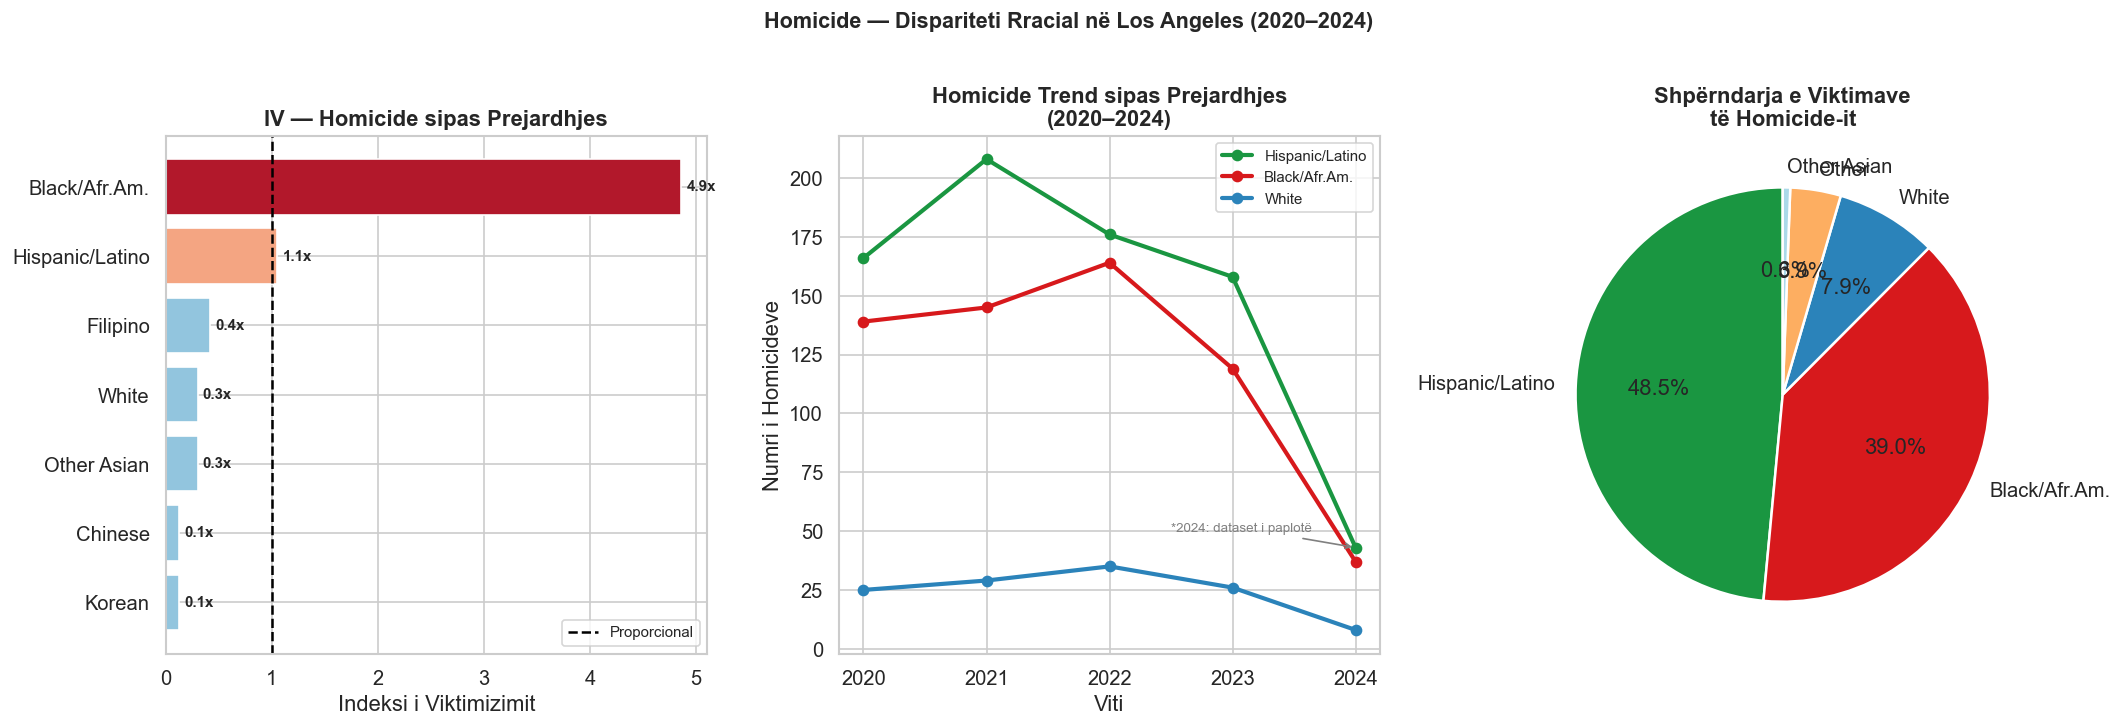

=== IV Homicide ===
          Grupi  Homicide_%  Popullsia_%  IV_Homicide
  Black/Afr.Am.   40.347361          8.3         4.86
Hispanic/Latino   50.167001         47.7         1.05
       Filipino    0.334001          0.8         0.42
    Other Asian    0.601202          2.0         0.30
          White    8.216433         27.8         0.30
        Chinese    0.200401          1.5         0.13
         Korean    0.133601          1.0         0.13


In [9]:
homicides = df[(df['Crm Cd Desc'] == 'CRIMINAL HOMICIDE') & df['Year'].between(2020, 2024)].copy()
homicides['Descent Name'] = homicides['Vict Descent'].map(descent_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Panel 1: IV për homicide ---
h_known = homicides[homicides['Descent Name'].isin(main_groups)]
h_pct = (h_known['Descent Name'].value_counts(normalize=True) * 100).reset_index()
h_pct.columns = ['Grupi', 'Homicide_%']
h_pct['Popullsia_%'] = h_pct['Grupi'].map(pop_pct)
h_pct['IV_Homicide'] = (h_pct['Homicide_%'] / h_pct['Popullsia_%']).round(2)
h_pct = h_pct.sort_values('IV_Homicide', ascending=True)

bar_colors = ['#b2182b' if iv > 2 else '#f4a582' if iv > 1 else '#92c5de' for iv in h_pct['IV_Homicide']]
b = axes[0].barh(h_pct['Grupi'], h_pct['IV_Homicide'], color=bar_colors, edgecolor='white')
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='Proporcional')
axes[0].set_title('IV — Homicide sipas Prejardhjes', fontweight='bold')
axes[0].set_xlabel('Indeksi i Viktimizimit')
axes[0].legend(fontsize=9)
for bar, iv in zip(b, h_pct['IV_Homicide']):
    axes[0].text(iv + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{iv:.1f}x', va='center', fontsize=9, fontweight='bold')

# --- Panel 2: Trend vjetor (H, B, W) ---
trend_groups = {'H': 'Hispanic/Latino', 'B': 'Black/Afr.Am.', 'W': 'White'}
trend_colors = {'H': '#1a9641', 'B': '#d7191c', 'W': '#2b83ba'}
for code, name in trend_groups.items():
    data = homicides[homicides['Vict Descent'] == code].groupby('Year').size()
    axes[1].plot(data.index, data.values, marker='o', linewidth=2.5, color=trend_colors[code], label=name)
axes[1].set_title('Homicide Trend sipas Prejardhjes\n(2020–2024)', fontweight='bold')
axes[1].set_xlabel('Viti')
axes[1].set_ylabel('Numri i Homicideve')
axes[1].legend(fontsize=9)
axes[1].set_xticks([2020, 2021, 2022, 2023, 2024])
# Shënim: 2024 = dataset i paplotë
axes[1].annotate('*2024: dataset i paplotë', xy=(2024, 43), xytext=(2022.5, 50),
                 fontsize=8, color='gray',
                 arrowprops=dict(arrowstyle='->', color='gray'))

# --- Panel 3: Pie chart për homicide sipas prejardhjes ---
top_h_groups = homicides[homicides['Vict Descent'].isin(['H','B','W','O','A'])]
pie_data = top_h_groups['Descent Name'].value_counts()
colors_pie = ['#1a9641','#d7191c','#2b83ba','#fdae61','#abd9e9']
axes[2].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[2].set_title('Shpërndarja e Viktimave\ntë Homicide-it', fontweight='bold')

plt.suptitle('Homicide — Dispariteti Rracial në Los Angeles (2020–2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('=== IV Homicide ===')
print(h_pct[['Grupi','Homicide_%','Popullsia_%','IV_Homicide']].sort_values('IV_Homicide', ascending=False).to_string(index=False))

### 🔍 Interpretimi — Homicidet

**Black/African American IV ≈ 4.9x** — Ky numër është ndër indikatorët më të lartë të dhunës strukturore urbane.

**Konteksti — Aktiviteti i Bandave (Cartel/Gang Activity):**
> Sipas raportit të **LAPD Gang Enforcement Detail (2022)**, Los Angeles ka mbi **450 banda aktive** me rreth **45,000 anëtarë të identifikuar**. Lagjet me aktivitet të lartë bande si **South LA, Watts, Compton** janë me shumicë Black dhe Hispanic — duke shpjeguar një pjesë të konsiderueshme të homicideve.
> Kartelët meksikanë (Sinaloa, CJNG) operojnë në LA kryesisht nëpërmjet rrjeteve vendase të shpërndarjes, duke ndikuar indirekt në normat e homicidit Hispanic.
> *(Burimi: Los Angeles Police Department Yearbook 2022; DEA Los Angeles Field Division Report 2023)*

**Çfarë nuk shpjegojnë të dhënat direkt:**
- Dataset-i i LAPD **nuk etiketon** krimet si "gang-related" apo "cartel-related" — kjo informacion vjen nga raporte të veçanta të LAPD Gang Division
- Homicidet e pashpjeguara (~30% sipas FBI UCR 2022) krijojnë pasiguri statistikore

## Grafiku 3 — Matrica e Llojeve të Krimeve sipas Prejardhjes (Heatmap)

**Pyetja:** Cilat lloje krimesh kanë përqendrimin më të lartë brenda secilit grup etnik (relativisht)?

<small>Ky kod krijon `subset_hm` nga `top_crimes_hm` dhe `top_groups_hm`, ndërton `pivot_hm = subset_hm.groupby(['Descent Name','Crm Cd Desc']).size().unstack(fill_value=0)` dhe e normalizon në `% brenda grupit` me `pivot_hm_norm`. Heatmap-i paraqet këto përqindje; vlera e lartë tregon se ai lloj krimi përbën një pjesë të madhe të shpërndarjes së krimeve për grupin përkatës.</small>

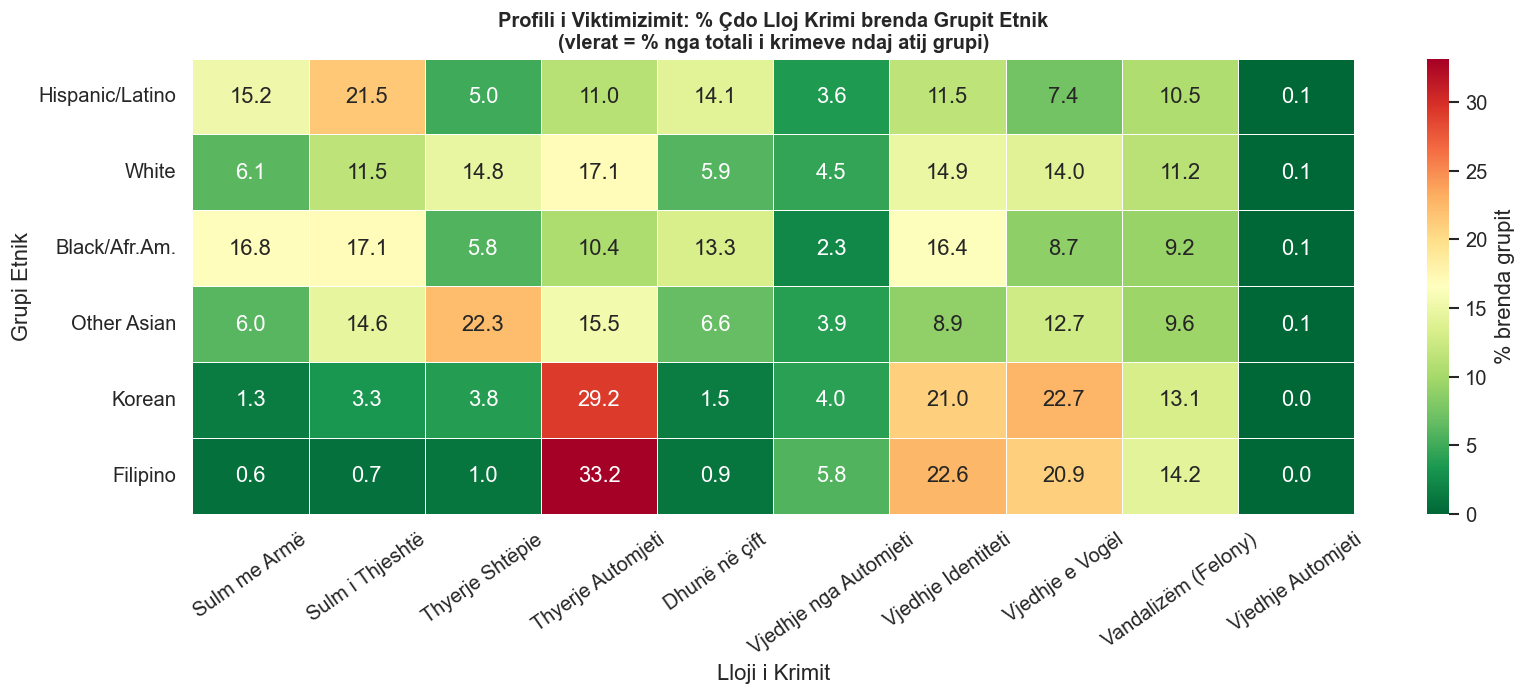

In [10]:
# Top 10 krimet dhe top 6 grupet
top_crimes_hm = df['Crm Cd Desc'].value_counts().head(10).index.tolist()
top_groups_hm = ['Hispanic/Latino','White','Black/Afr.Am.','Other Asian','Korean','Filipino']

subset_hm = df[df['Descent Name'].isin(top_groups_hm) & df['Crm Cd Desc'].isin(top_crimes_hm)].copy()

# Normalizojmë brenda çdo grupi (profili relativ)
pivot_hm = subset_hm.groupby(['Descent Name','Crm Cd Desc']).size().unstack(fill_value=0)
pivot_hm_norm = pivot_hm.div(pivot_hm.sum(axis=1), axis=0) * 100  # % brenda grupit
pivot_hm_norm = pivot_hm_norm.loc[top_groups_hm]

# Shkurto etiketat
short_names = {
    'VEHICLE - STOLEN': 'Vjedhje Automjeti',
    'BATTERY - SIMPLE ASSAULT': 'Sulm i Thjeshtë',
    'BURGLARY FROM VEHICLE': 'Thyerje Automjeti',
    'THEFT OF IDENTITY': 'Vjedhje Identiteti',
    'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)': 'Vandalizëm (Felony)',
    'BURGLARY': 'Thyerje Shtëpie',
    'THEFT PLAIN - PETTY ($950 & UNDER)': 'Vjedhje e Vogël',
    'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT': 'Sulm me Armë',
    'INTIMATE PARTNER - SIMPLE ASSAULT': 'Dhunë në çift',
    'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)': 'Vjedhje nga Automjeti'
}
pivot_hm_norm.columns = [short_names.get(c, c[:25]) for c in pivot_hm_norm.columns]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_hm_norm, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax, cbar_kws={'label': '% brenda grupit'},
            linewidths=0.5, linecolor='white')
ax.set_title('Profili i Viktimizimit: % Çdo Lloj Krimi brenda Grupit Etnik\n(vlerat = % nga totali i krimeve ndaj atij grupi)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Lloji i Krimit')
ax.set_ylabel('Grupi Etnik')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

---
## Grafiku 4 — Krimet me Armë Zjarri sipas Prejardhjes

Armët e zjarrit janë indikator i **aktivitetit gangsterik/kartel** — jo vetëm i agresionit individual.

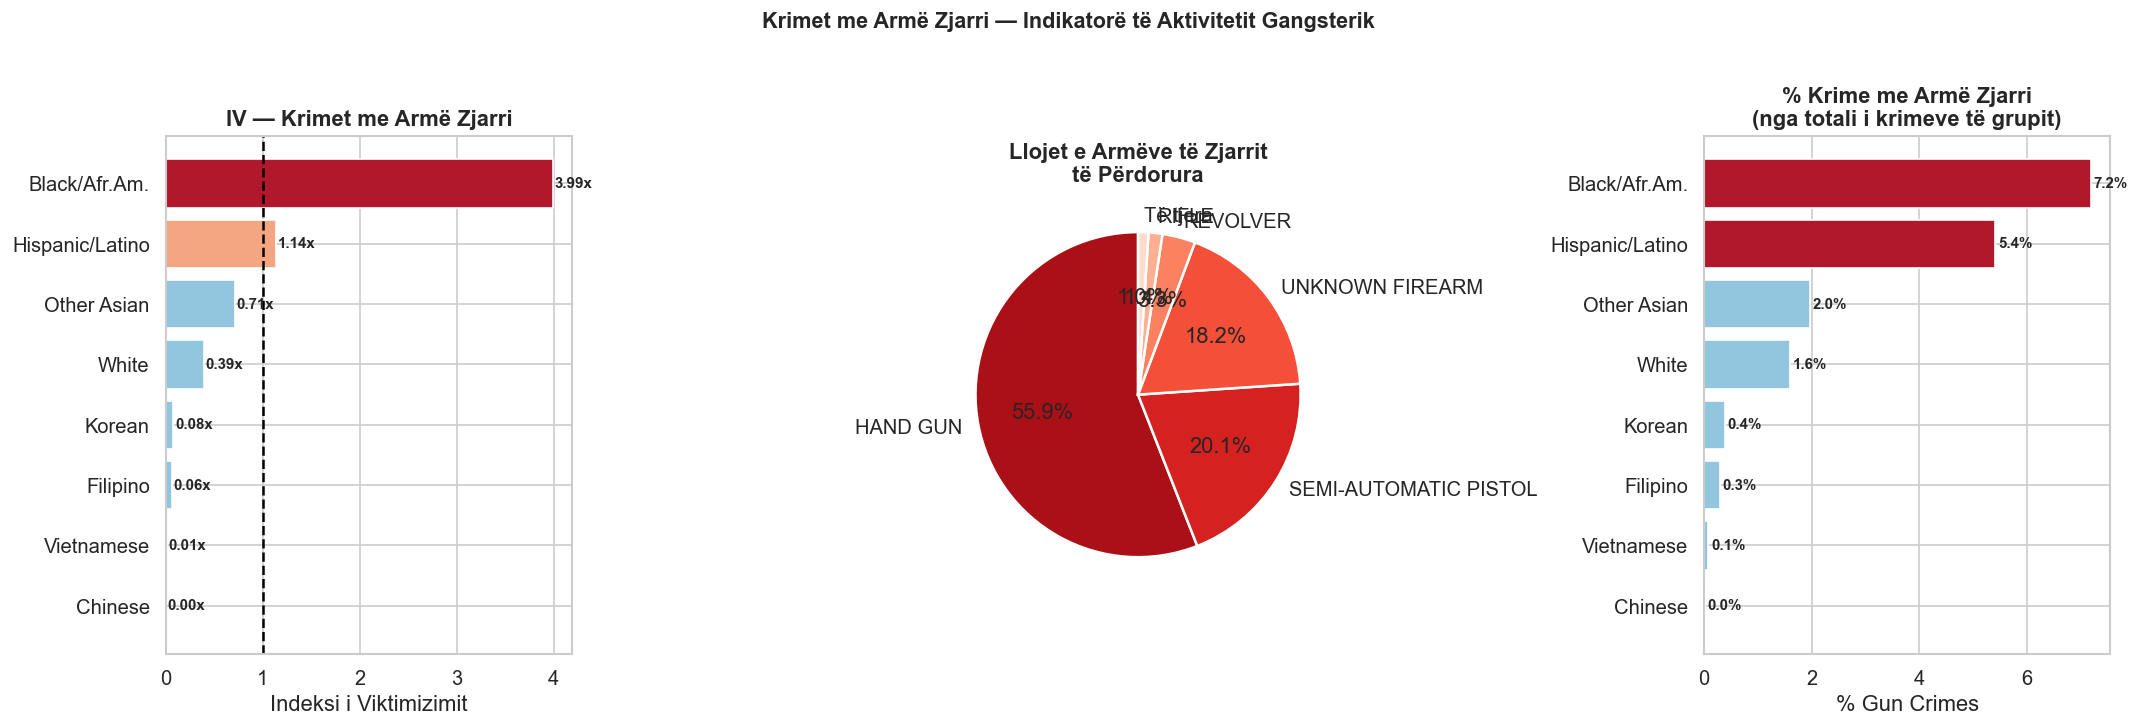

In [11]:
# Krimet me armë zjarri
gun_keywords = ['HAND GUN', 'SEMI-AUTOMATIC PISTOL', 'UNKNOWN FIREARM', 'REVOLVER',
                'SEMI-AUTOMATIC RIFLE', 'RIFLE', 'SHOTGUN', 'ASSAULT WEAPON']
gun_df = df[df['Weapon Desc'].isin(gun_keywords)].copy()
gun_df['Descent Name'] = gun_df['Vict Descent'].map(descent_map)
gun_main = gun_df[gun_df['Descent Name'].isin(main_groups)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Panel 1: IV për krimet me armë zjarri ---
gun_pct = (gun_main['Descent Name'].value_counts(normalize=True) * 100).reset_index()
gun_pct.columns = ['Grupi', 'Gun_%']
gun_pct['Popullsia_%'] = gun_pct['Grupi'].map(pop_pct)
gun_pct['IV_Gun'] = (gun_pct['Gun_%'] / gun_pct['Popullsia_%']).round(2)
gun_pct = gun_pct.sort_values('IV_Gun', ascending=True)

colors_g = ['#b2182b' if iv > 2 else '#f4a582' if iv > 1 else '#92c5de' for iv in gun_pct['IV_Gun']]
b = axes[0].barh(gun_pct['Grupi'], gun_pct['IV_Gun'], color=colors_g, edgecolor='white')
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title('IV — Krimet me Armë Zjarri', fontweight='bold')
axes[0].set_xlabel('Indeksi i Viktimizimit')
for bar, iv in zip(b, gun_pct['IV_Gun']):
    axes[0].text(iv + 0.02, bar.get_y() + bar.get_height()/2, f'{iv:.2f}x', va='center', fontsize=9, fontweight='bold')

# --- Panel 2: Lloji i armës (pie) ---
weapon_counts = gun_df['Weapon Desc'].value_counts()
top_w = weapon_counts.head(5)
other_w = weapon_counts.iloc[5:].sum()
pie_labels = list(top_w.index) + ['Të tjera']
pie_vals   = list(top_w.values) + [other_w]
colors_w   = sns.color_palette('Reds_r', len(pie_labels))
axes[1].pie(pie_vals, labels=pie_labels, autopct='%1.1f%%', colors=colors_w,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Llojet e Armëve të Zjarrit\ntë Përdorura', fontweight='bold')

# --- Panel 3: Gun crime vs total crime ratio by descent ---
total_by_descent = df_known['Descent Name'].value_counts().reset_index()
total_by_descent.columns = ['Grupi','Total']
gun_by_descent = gun_main['Descent Name'].value_counts().reset_index()
gun_by_descent.columns = ['Grupi','Gun']
merged = total_by_descent.merge(gun_by_descent, on='Grupi')
merged['Gun_Ratio_%'] = (merged['Gun'] / merged['Total'] * 100).round(2)
merged = merged.sort_values('Gun_Ratio_%', ascending=True)

c_ratio = ['#b2182b' if r > 5 else '#f4a582' if r > 3 else '#92c5de' for r in merged['Gun_Ratio_%']]
axes[2].barh(merged['Grupi'], merged['Gun_Ratio_%'], color=c_ratio, edgecolor='white')
axes[2].set_title('% Krime me Armë Zjarri\n(nga totali i krimeve të grupit)', fontweight='bold')
axes[2].set_xlabel('% Gun Crimes')
for i, (idx, row) in enumerate(merged.iterrows()):
    axes[2].text(row['Gun_Ratio_%'] + 0.05, i,
                 f"{row['Gun_Ratio_%']:.1f}%", va='center', fontsize=9, fontweight='bold')

plt.suptitle('Krimet me Armë Zjarri — Indikatorë të Aktivitetit Gangsterik',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Grafik 4 - V2 (better)

## Grafiku 4 — Krimet me Armë Zjarri sipas Prejardhjes dhe armët me të përdorura

**Pyetja:** Për cilat grupe është më i lartë Indeksi i Viktimizimit për krimet me armë zjarri dhe cilat lloje armësh dominojnë?

<small>Ky seksion filtron `gun_df` me `gun_keywords`, llogarit `gun_pct` (% e krimeve me armë brenda grupit) dhe `IV_Gun = Gun_% / Popullsia_%`. Më pas vizaton `barh` për `IV_Gun`, një `pie` për llojet kryesore të armëve dhe një barh për `% Krime me Armë` ndaj totalit për secilin grup. Përgjigjja merret nga `IV_Gun`, `weapon_counts` dhe `merged['Gun_Ratio_%']` në kod.</small>

Weapon Desc
UNKNOWN                                           677918
STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)    174777
UNKNOWN WEAPON/OTHER WEAPON                        36394
VERBAL THREAT                                      23848
HAND GUN                                           20186
SEMI-AUTOMATIC PISTOL                               7267
KNIFE WITH BLADE 6INCHES OR LESS                    6841
UNKNOWN FIREARM                                     6581
OTHER KNIFE                                         5880
MACE/PEPPER SPRAY                                   3730
VEHICLE                                             3260
ROCK/THROWN OBJECT                                  2739
PIPE/METAL PIPE                                     2469
BOTTLE                                              2415
FOLDING KNIFE                                       2266
STICK                                               2249
CLUB/BAT                                            2088
KITCHEN KNIFE      

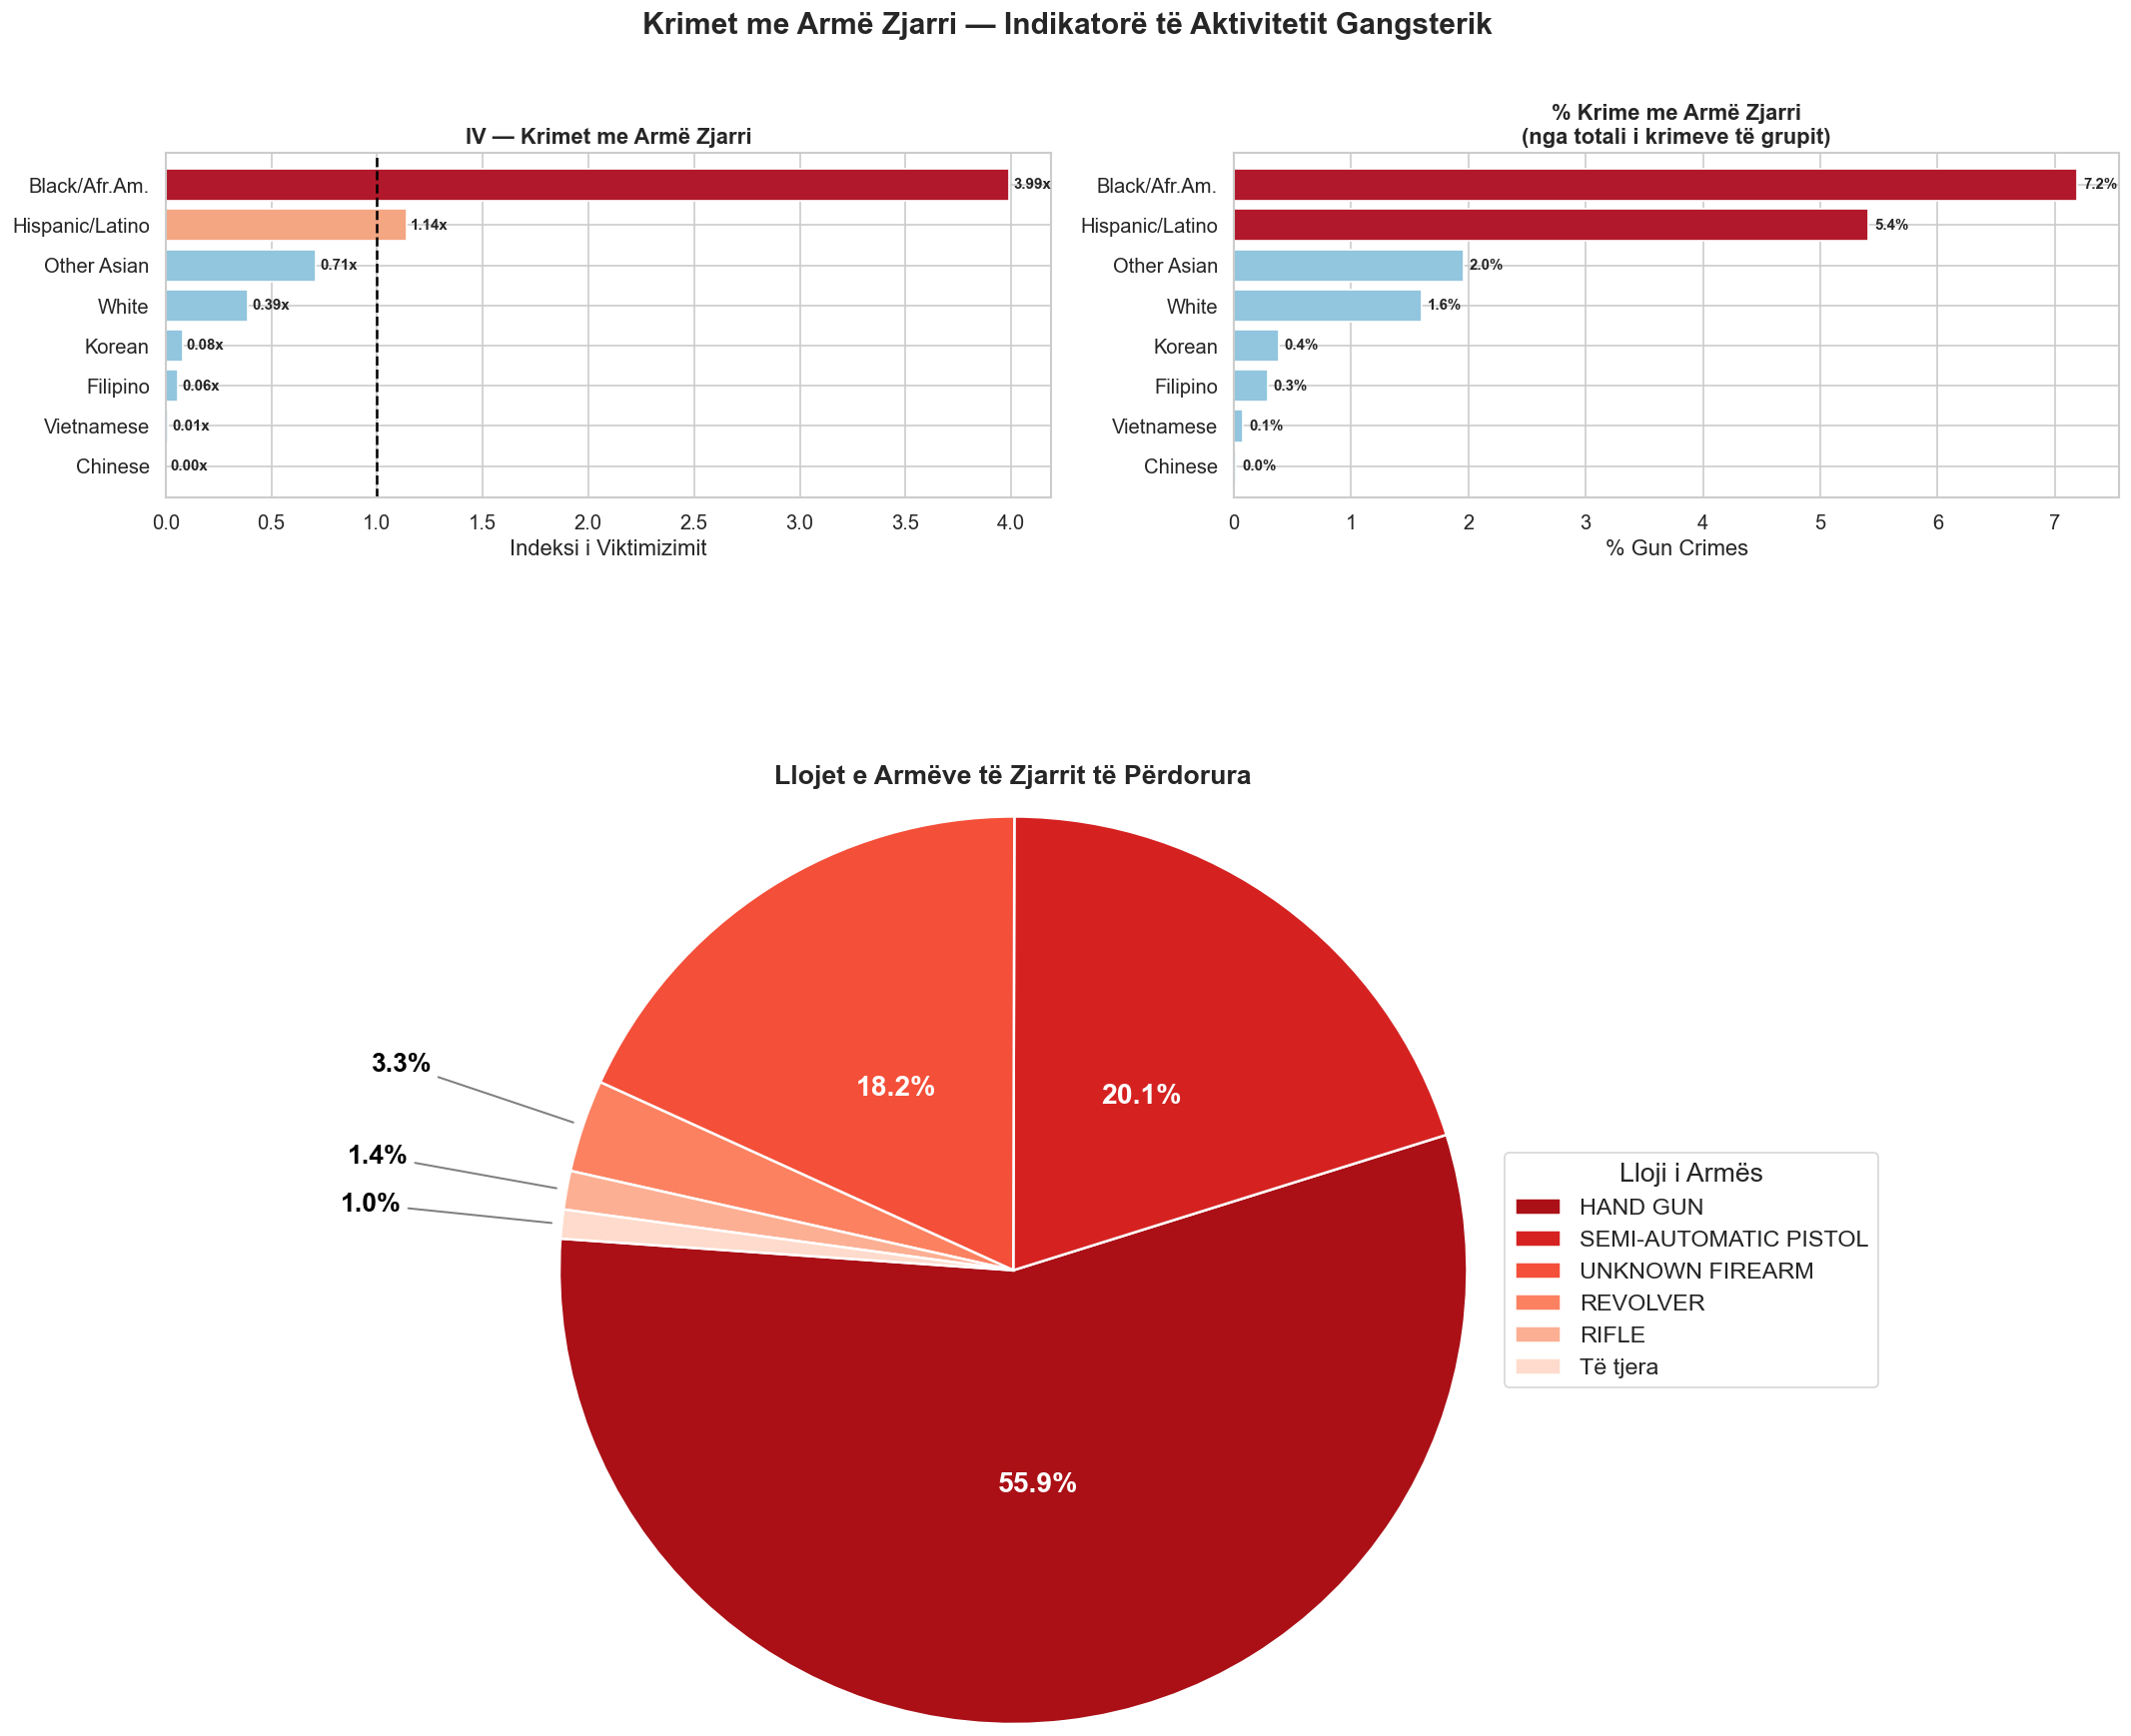

In [12]:
# Krimet me armë zjarri
print(df['Weapon Desc'].value_counts().head(40))
gun_keywords = ['HAND GUN', 'SEMI-AUTOMATIC PISTOL', 'UNKNOWN FIREARM', 'REVOLVER',
                'SEMI-AUTOMATIC RIFLE', 'RIFLE', 'SHOTGUN', 'ASSAULT WEAPON']
gun_df = df[df['Weapon Desc'].isin(gun_keywords)].copy()
gun_df['Descent Name'] = gun_df['Vict Descent'].map(descent_map)
gun_main = gun_df[gun_df['Descent Name'].isin(main_groups)]

fig = plt.figure(figsize=(18, 14))

# --- Panel 1: IV për krimet me armë zjarri (top-left) ---
ax1 = fig.add_subplot(2, 2, 1)
gun_pct = (gun_main['Descent Name'].value_counts(normalize=True) * 100).reset_index()
gun_pct.columns = ['Grupi', 'Gun_%']
gun_pct['Popullsia_%'] = gun_pct['Grupi'].map(pop_pct)
gun_pct['IV_Gun'] = (gun_pct['Gun_%'] / gun_pct['Popullsia_%']).round(2)
gun_pct = gun_pct.sort_values('IV_Gun', ascending=True)

colors_g = ['#b2182b' if iv > 2 else '#f4a582' if iv > 1 else '#92c5de' for iv in gun_pct['IV_Gun']]
b = ax1.barh(gun_pct['Grupi'], gun_pct['IV_Gun'], color=colors_g, edgecolor='white')
ax1.axvline(1.0, color='black', linestyle='--', linewidth=1.5)
ax1.set_title('IV — Krimet me Armë Zjarri', fontweight='bold')
ax1.set_xlabel('Indeksi i Viktimizimit')
for bar, iv in zip(b, gun_pct['IV_Gun']):
    ax1.text(iv + 0.02, bar.get_y() + bar.get_height()/2, f'{iv:.2f}x', va='center', fontsize=9, fontweight='bold')

# --- Panel 2: Gun crime vs total crime ratio by descent (top-right) ---
ax2 = fig.add_subplot(2, 2, 2)
total_by_descent = df_known['Descent Name'].value_counts().reset_index()
total_by_descent.columns = ['Grupi','Total']
gun_by_descent = gun_main['Descent Name'].value_counts().reset_index()
gun_by_descent.columns = ['Grupi','Gun']
merged = total_by_descent.merge(gun_by_descent, on='Grupi')
merged['Gun_Ratio_%'] = (merged['Gun'] / merged['Total'] * 100).round(2)
merged = merged.sort_values('Gun_Ratio_%', ascending=True)

c_ratio = ['#b2182b' if r > 5 else '#f4a582' if r > 3 else '#92c5de' for r in merged['Gun_Ratio_%']]
ax2.barh(merged['Grupi'], merged['Gun_Ratio_%'], color=c_ratio, edgecolor='white')
ax2.set_title('% Krime me Armë Zjarri\n(nga totali i krimeve të grupit)', fontweight='bold')
ax2.set_xlabel('% Gun Crimes')
for i, (idx, row) in enumerate(merged.iterrows()):
    ax2.text(row['Gun_Ratio_%'] + 0.05, i,
             f"{row['Gun_Ratio_%']:.1f}%", va='center', fontsize=9, fontweight='bold')

# --- Panel 3: Pie chart centered in bottom row (spans both columns) ---
ax3 = fig.add_subplot(2, 1, 2)
ax3.set_visible(False)
ax3_pie = fig.add_axes([0.05, 0.0, 0.85, 0.52])

weapon_counts = gun_df['Weapon Desc'].value_counts()
top_w = weapon_counts.head(5)
other_w = weapon_counts.iloc[5:].sum()
pie_labels = list(top_w.index) + ['Të tjera']
pie_vals   = list(top_w.values) + [other_w]
colors_w   = sns.color_palette('Reds_r', len(pie_labels))

wedges, texts = ax3_pie.pie(
    pie_vals,
    labels=None,
    autopct=None,
    colors=colors_w,
    startangle=176,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    radius=1.3
)

for i, (wedge, val) in enumerate(zip(wedges, pie_vals)):
    pct = val / sum(pie_vals) * 100
    angle = (wedge.theta1 + wedge.theta2) / 2
    angle_rad = np.deg2rad(angle)
    slice_size = wedge.theta2 - wedge.theta1

    if slice_size < 15:
        r_text = 1.85
        x_text = r_text * np.cos(angle_rad)
        y_text = r_text * np.sin(angle_rad)
        x1 = 1.32 * np.cos(angle_rad)
        y1 = 1.32 * np.sin(angle_rad)
        ax3_pie.annotate(
            f'{pct:.1f}%',
            xy=(x1, y1),
            xytext=(x_text, y_text),
            fontsize=16,
            fontweight='bold',
            color='black',
            ha='center', va='center',
            arrowprops=dict(arrowstyle='-', color='gray', lw=1.2),
            annotation_clip=False  # ← kjo lejon tekstin jashtë axes
        )
    else:
        r_text = 0.62
        x_text = r_text * np.cos(angle_rad)
        y_text = r_text * np.sin(angle_rad)
        ax3_pie.text(
            x_text, y_text, f'{pct:.1f}%',
            ha='center', va='center',
            fontsize=17, fontweight='bold', color='white'
        )

ax3_pie.legend(
    wedges,
    pie_labels,
    title='Lloji i Armës',
    loc='center left',
    bbox_to_anchor=(1.05, 0, 0.5, 1),
    fontsize=14,
    title_fontsize=16
)

ax3_pie.set_title('Llojet e Armëve të Zjarrit të Përdorura', fontweight='bold', fontsize=16, pad=30)

plt.suptitle('Krimet me Armë Zjarri — Indikatorë të Aktivitetit Gangsterik',
             fontsize=18, fontweight='bold', y=1.01)

plt.tight_layout(rect=[0, 0.45, 1, 1])
plt.show()

## Grafiku 5 — Moshat më të viktimizuara (Prejardhja × Gjinia)

**Pyetja:** Cilat grupmosha dhe kombinime prejardhje×gjinia shfaqin numrin më të lartë të viktimave?

Këtu përdorim `main_groups` për `Descent Name` dhe krijojmë disa grafiqe (grouped bar, stacked bar, heatmap) që shprehin insight-e në forma të ndryshme.

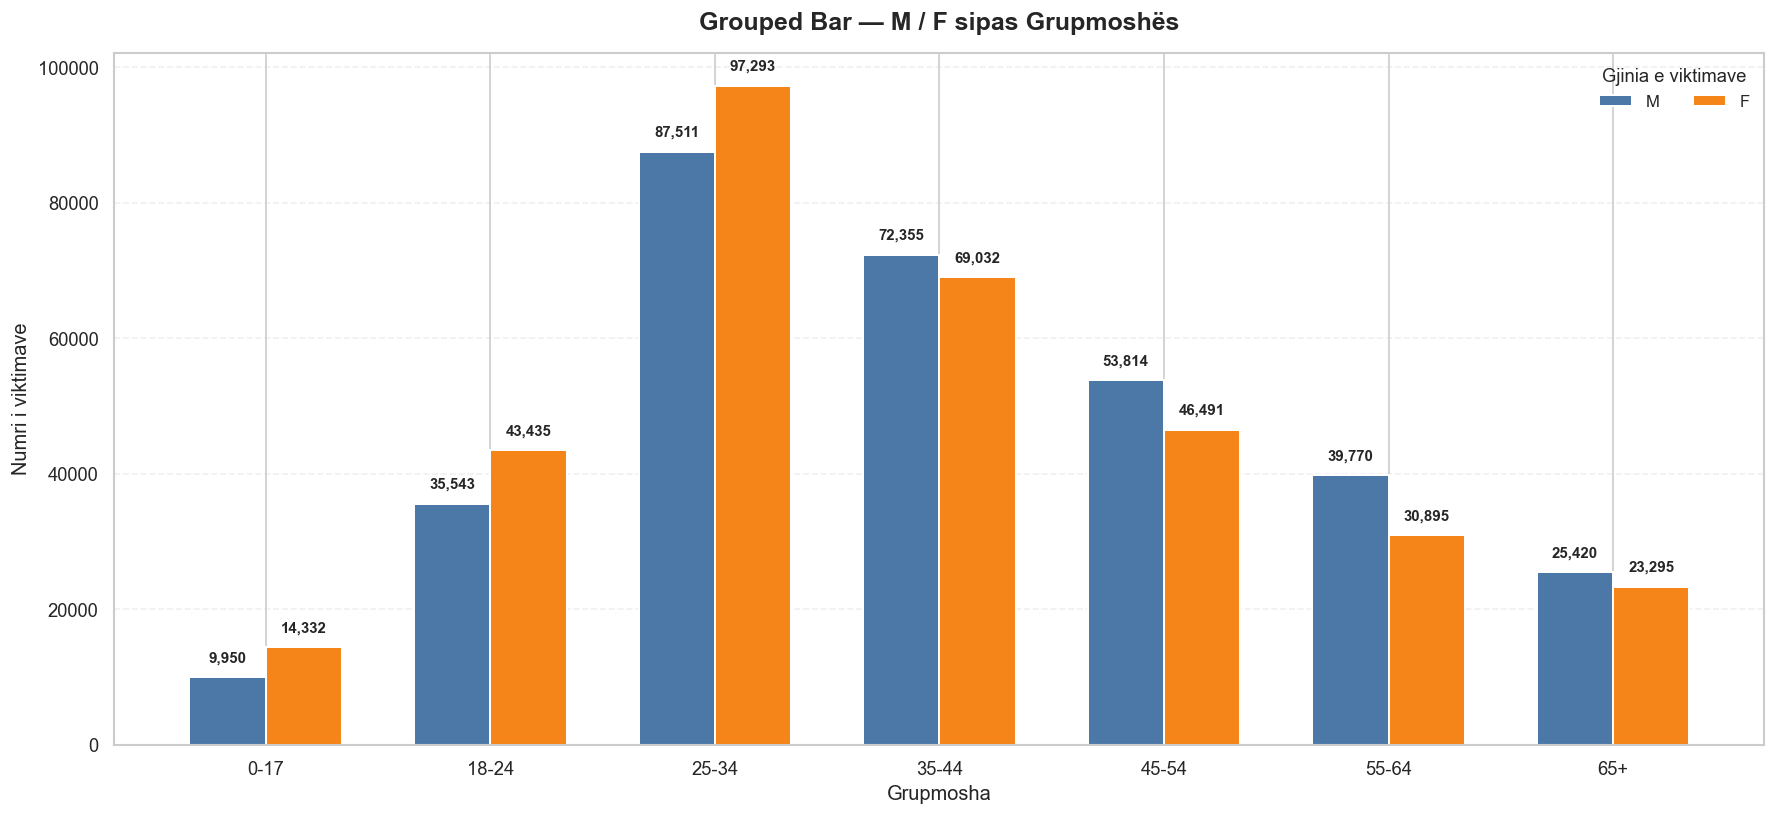

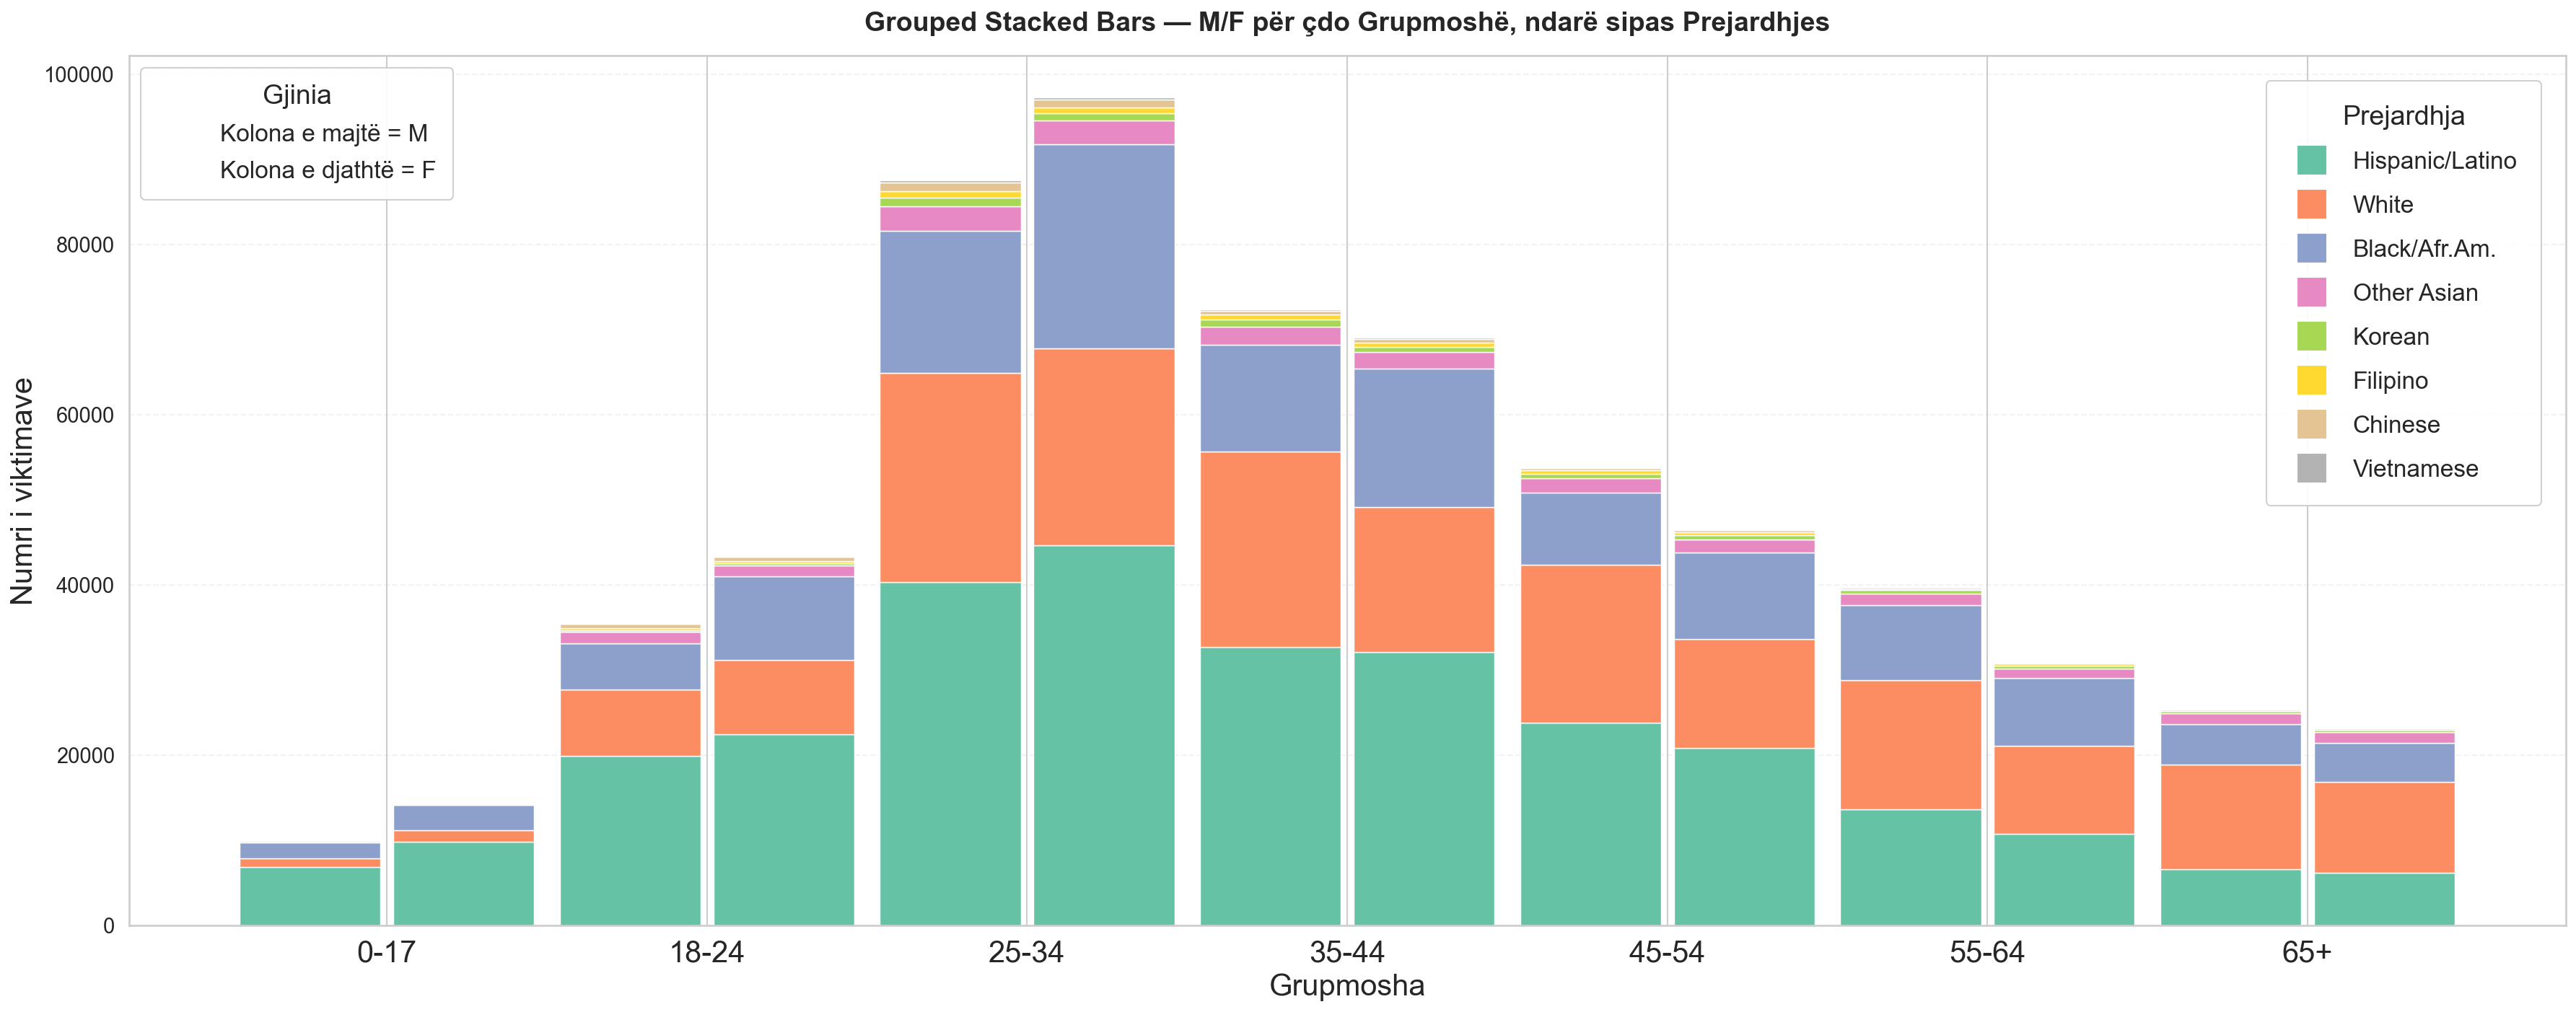

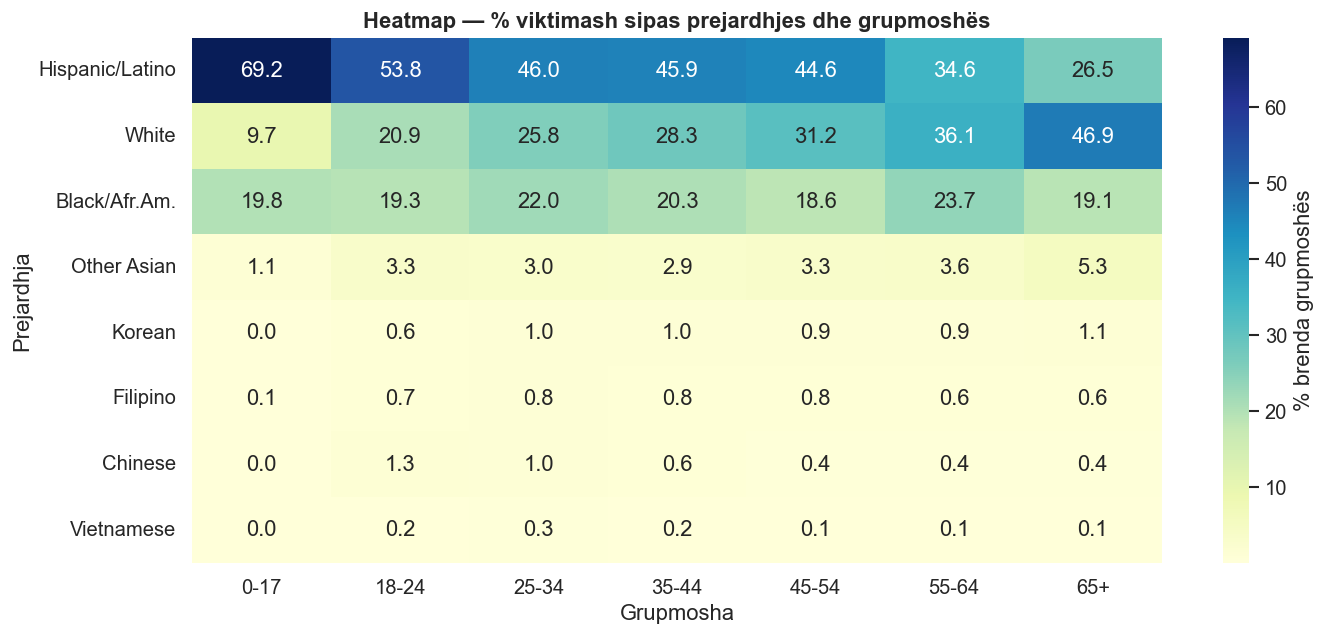


=== Top Race×Gender për çdo Grupmoshe ===

Grupmosha: 0-17
   Descent Name Vict Sex  Count
Hispanic/Latino        F   9899
Hispanic/Latino        M   6898
  Black/Afr.Am.        F   2932
  Black/Afr.Am.        M   1886
          White        F   1329
          White        M   1020

Grupmosha: 18-24
   Descent Name Vict Sex  Count
Hispanic/Latino        F  22496
Hispanic/Latino        M  19966
  Black/Afr.Am.        F   9858
          White        F   8683
          White        M   7786
  Black/Afr.Am.        M   5402

Grupmosha: 25-34
   Descent Name Vict Sex  Count
Hispanic/Latino        F  44629
Hispanic/Latino        M  40390
          White        M  24560
  Black/Afr.Am.        F  23974
          White        F  23203
  Black/Afr.Am.        M  16647

Grupmosha: 35-44
   Descent Name Vict Sex  Count
Hispanic/Latino        M  32721
Hispanic/Latino        F  32173
          White        M  22969
          White        F  16995
  Black/Afr.Am.        F  16221
  Black/Afr.Am.       

In [13]:
# Përgatitja e të dhënave
age_bins = [0, 17, 24, 34, 44, 54, 64, 150]
age_labels = ['0-17','18-24','25-34','35-44','45-54','55-64','65+']

df_age = df.copy()
# Ruajmë vetëm rekordet me moshë të vlefshme >0 dhe me prejardhje nga main_groups
df_age = df_age[df_age['Vict Age'].notnull() & (df_age['Vict Age'] > 0)]
df_age['Descent Name'] = df_age['Vict Descent'].map(descent_map)
df_age = df_age[df_age['Descent Name'].isin(main_groups)].copy()

if df_age.empty:
    print('Nuk ka rekorde të vlefshme për grupet kryesore (main_groups).')
else:
    df_age['AgeGroup'] = pd.cut(df_age['Vict Age'], bins=age_bins, labels=age_labels, right=True)
    # Mbajmë vetëm gjinitë M dhe F
    df_age['Vict Sex'] = df_age['Vict Sex'].fillna('X').replace({'': 'X', '-': 'X'})
    df_age = df_age[df_age['Vict Sex'].isin(['M', 'F'])].copy()

    counts = df_age.groupby(['AgeGroup', 'Descent Name', 'Vict Sex']).size().reset_index(name='Count')
    counts = counts[counts['Count'] > 0].copy()
    counts['Race_Gender'] = counts['Descent Name'] + ' | ' + counts['Vict Sex']

    # 1) Grouped bar chart: M/F brenda çdo grupmoshe
    sex_order = ['M', 'F']
    sex_colors = {'M': '#4c78a8', 'F': '#f58518'}
    age_sex = counts.groupby(['AgeGroup', 'Vict Sex'])['Count'].sum().reset_index()
    age_sex_pivot = age_sex.pivot(index='AgeGroup', columns='Vict Sex', values='Count').reindex(age_labels).fillna(0)
    age_sex_pivot = age_sex_pivot.reindex(columns=sex_order).fillna(0)

    x = np.arange(len(age_labels))
    width = 0.34
    fig1, ax1 = plt.subplots(figsize=(15, 7))
    for i, sex in enumerate(sex_order):
        values = age_sex_pivot[sex].values
        offset = (i - 0.5) * width
        ax1.bar(x + offset, values, width, label=sex, color=sex_colors[sex], edgecolor='white', linewidth=1.2)
        for xi, yi in zip(x + offset, values):
            if yi > 0:
                ax1.text(xi, yi + max(age_sex_pivot.sum(axis=1).max() * 0.01, 10), f'{int(yi):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax1.set_title('Grouped Bar — M / F sipas Grupmoshës', fontweight='bold', fontsize=15, pad=14)
    ax1.set_xlabel('Grupmosha', fontsize=12)
    ax1.set_ylabel('Numri i viktimave', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(age_labels, fontsize=11)
    ax1.tick_params(axis='y', labelsize=11)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    ax1.set_axisbelow(True)
    ax1.legend(title='Gjinia e viktimave', fontsize=10, title_fontsize=11, frameon=False, ncols=2)
    plt.tight_layout()
    plt.show()

    # 2) Grouped stacked bars: 2 bars per AgeGroup (M dhe F), secila e ndarë sipas prejardhjes
    fig2, ax2 = plt.subplots(figsize=(24, 10), dpi=150)
    descent_palette = sns.color_palette('Set2', n_colors=len(main_groups))
    descent_colors = {grp: descent_palette[i] for i, grp in enumerate(main_groups)}

    sex_positions = {'M': -0.24, 'F': 0.24}
    bar_width = 0.44

    for sex in sex_order:
        sub = counts[counts['Vict Sex'] == sex].copy()
        sex_pivot = sub.groupby(['AgeGroup', 'Descent Name'])['Count'].sum().reset_index()
        sex_pivot = sex_pivot.pivot(index='AgeGroup', columns='Descent Name', values='Count').reindex(age_labels).fillna(0)
        sex_pivot = sex_pivot.reindex(columns=main_groups).fillna(0)

        bottom = np.zeros(len(age_labels))
        for grp in main_groups:
            values = sex_pivot[grp].values if grp in sex_pivot.columns else np.zeros(len(age_labels))
            ax2.bar(
                x + sex_positions[sex],
                values,
                width=bar_width,
                bottom=bottom,
                label=grp if sex == sex_order[0] else None,
                color=descent_colors[grp],
                edgecolor='white',
                linewidth=0.7,
            )
            bottom += values

        ax2.bar(
            x + sex_positions[sex],
            np.zeros(len(age_labels)),
            width=bar_width,
            color='none',
            edgecolor='none',
            label=sex,
        )

    ax2.set_title('Grouped Stacked Bars — M/F për çdo Grupmoshë, ndarë sipas Prejardhjes', fontweight='bold', fontsize=18, pad=17)
    ax2.set_xlabel('Grupmosha', fontsize=20)
    ax2.set_ylabel('Numri i viktimave', fontsize=20)
    ax2.set_xticks(x)
    ax2.set_xticklabels(age_labels, fontsize=20)
    ax2.tick_params(axis='y', labelsize=14)
    ax2.grid(axis='y', linestyle='--', alpha=0.25)
    ax2.set_axisbelow(True)

    sex_handles = [
        plt.Line2D([0], [0], marker='s', color='w', label='Kolona e majtë = M', markersize=20),
        plt.Line2D([0], [0], marker='s', color='w', label='Kolona e djathtë = F', markersize=20),
    ]
    descent_handles = [
        plt.Line2D([0], [0], marker='s', color='w', label=grp, markerfacecolor=descent_colors[grp], markersize=20)
        for grp in main_groups
    ]
    leg1 = ax2.legend(
        handles=sex_handles,
        title='Gjinia',
        loc='upper left',
        frameon=True,
        framealpha=0.92,
        edgecolor='0.8',
        facecolor='white',
        fancybox=True,
        fontsize=16,
        title_fontsize=18,
        borderpad=0.7,
        labelspacing=0.6,
        handletextpad=0.6,
    )
    ax2.add_artist(leg1)
    ax2.legend(
        handles=descent_handles,
        title='Prejardhja',
        loc='upper right',
        bbox_to_anchor=(0.995, 0.985),
        frameon=True,
        framealpha=0.92,
        edgecolor='0.8',
        facecolor='white',
        fancybox=True,
        fontsize=16,
        title_fontsize=18,
        borderpad=1.0,
        labelspacing=0.9,
        handlelength=1.8,
        handletextpad=0.8,
        ncol=1,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.955])
    plt.show()

    # 3) Heatmap: AgeGroup në x-axis, Descent Name në y-axis
    heat = counts.groupby(['AgeGroup', 'Descent Name'])['Count'].sum().reset_index()
    heat_pivot = heat.pivot(index='Descent Name', columns='AgeGroup', values='Count').reindex(main_groups).fillna(0)
    heat_pivot = heat_pivot.reindex(columns=age_labels).fillna(0)
    heat_pivot_pct = heat_pivot.div(heat_pivot.sum(axis=0), axis=1) * 100

    plt.figure(figsize=(12, 5.5))
    sns.heatmap(heat_pivot_pct, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '% brenda grupmoshës'})
    plt.title('Heatmap — % viktimash sipas prejardhjes dhe grupmoshës', fontweight='bold')
    plt.xlabel('Grupmosha')
    plt.ylabel('Prejardhja')
    plt.tight_layout()
    plt.show()

    # Print top combinations per age group for quick reference
    top_by_age = counts.groupby(['AgeGroup', 'Descent Name', 'Vict Sex'])['Count'].sum().reset_index()
    top_by_age = top_by_age.sort_values(['AgeGroup', 'Count'], ascending=[True, False])
    print('\n=== Top Race×Gender për çdo Grupmoshe ===')
    for ag in age_labels:
        sub = top_by_age[top_by_age['AgeGroup'] == ag].head(6)
        if sub.empty:
            continue
        print(f'\nGrupmosha: {ag}')
        print(sub[['Descent Name', 'Vict Sex', 'Count']].to_string(index=False))


# 6: Shpërndarja kohore e krimeve sipas llojit të vendndodhjes dhe kategorisë

**Pyetja:** Në cilat orë dhe në çfarë lloj vendndodhjes ndodhin më shumë krime për kategoritë Part 1 (të rënda) dhe Part 2 (më pak të rënda)?

<small>Ky grafik (heatmap) tregon përqindjen e krimeve brenda çdo lloji vendndodhjeje sipas orës (vlerat janë normalizuar brenda rreshtit — çdo "Premis" = 100%). Pikat më të ngjyrueshme tregojnë orët ku një premise ka përqendrimin më të madh të krimeve. Për kontekst dhe metoda, shiko Pyetjen 3 në `more_interesting_graphs.ipynb`.</small>

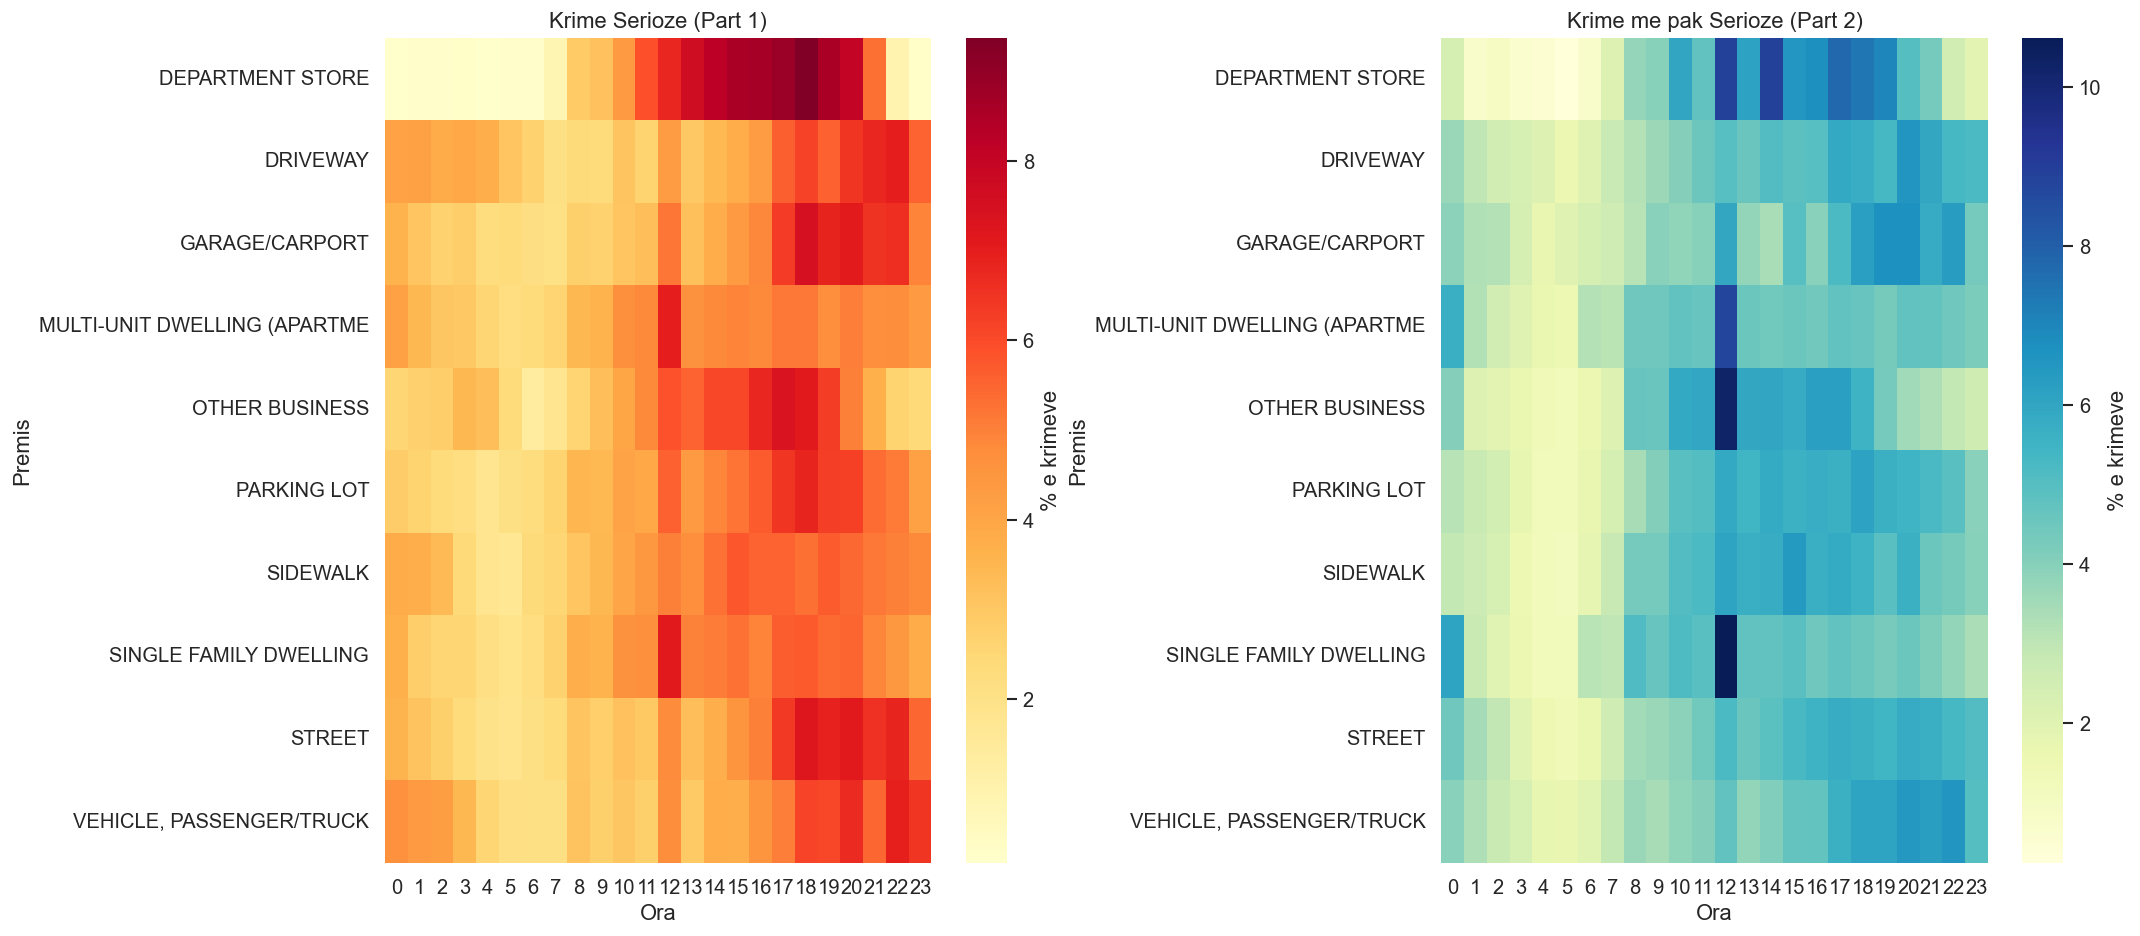

In [28]:
df_q3 = df.dropna(subset=["TIME OCC", "Premis Desc", "Part 1-2"]).copy()
df_q3["TIME OCC"] = pd.to_numeric(df_q3["TIME OCC"], errors="coerce")
df_q3["Part 1-2"] = pd.to_numeric(df_q3["Part 1-2"], errors="coerce")
df_q3 = df_q3.dropna(subset=["TIME OCC", "Part 1-2"])
df_q3["Hour"] = (df_q3["TIME OCC"] // 100).astype(int).clip(0, 23)

top_premis = df_q3["Premis Desc"].value_counts().head(10).index
df_top = df_q3[df_q3["Premis Desc"].isin(top_premis)].copy()
df_top["Premis_Short"] = df_top["Premis Desc"].str[:28]

part1_piv = df_top[df_top["Part 1-2"] == 1].groupby(["Premis_Short", "Hour"]).size().unstack(fill_value=0)
part2_piv = df_top[df_top["Part 1-2"] == 2].groupby(["Premis_Short", "Hour"]).size().unstack(fill_value=0)

part1_piv = part1_piv.reindex(columns=range(24), fill_value=0)
part2_piv = part2_piv.reindex(columns=range(24), fill_value=0)
part1_piv = part1_piv.div(part1_piv.sum(axis=1), axis=0) * 100
part2_piv = part2_piv.div(part2_piv.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(part1_piv, ax=axes[0], cmap="YlOrRd", cbar_kws={"label": "% e krimeve"})
sns.heatmap(part2_piv, ax=axes[1], cmap="YlGnBu", cbar_kws={"label": "% e krimeve"})

axes[0].set_title("Krime Serioze (Part 1)")
axes[1].set_title("Krime me pak Serioze (Part 2)")
axes[0].set_xlabel("Ora")
axes[1].set_xlabel("Ora")
axes[0].set_ylabel("Premis")
axes[1].set_ylabel("Premis")

plt.tight_layout()
plt.show()

# 7: Krimet me kalimin e kohës

**Pyetja:** Si ka ndryshuar numri i krimeve me kalimin e kohës në zonat më të prekura? A shfaqen trendë të dukshëm apo sezonalitet?

<small>Grafiku përdor seri kohore me mesatare lëvizëse (rolling mean) për të zbutur luhatjet ditore/mujore dhe për të nxjerrë trendët afatshkurtër. Paneli i poshtëm tregon sezonalinë mujore (normalizuar). Për shembull, një rritje konstante mund të tregojë vlerësime të rritjes së krimeve ose ndryshime në raportim. Shiko Pyetjen 6 në `more_interesting_graphs.ipynb` për referenca dhe stilizime të ngjashme.</small>

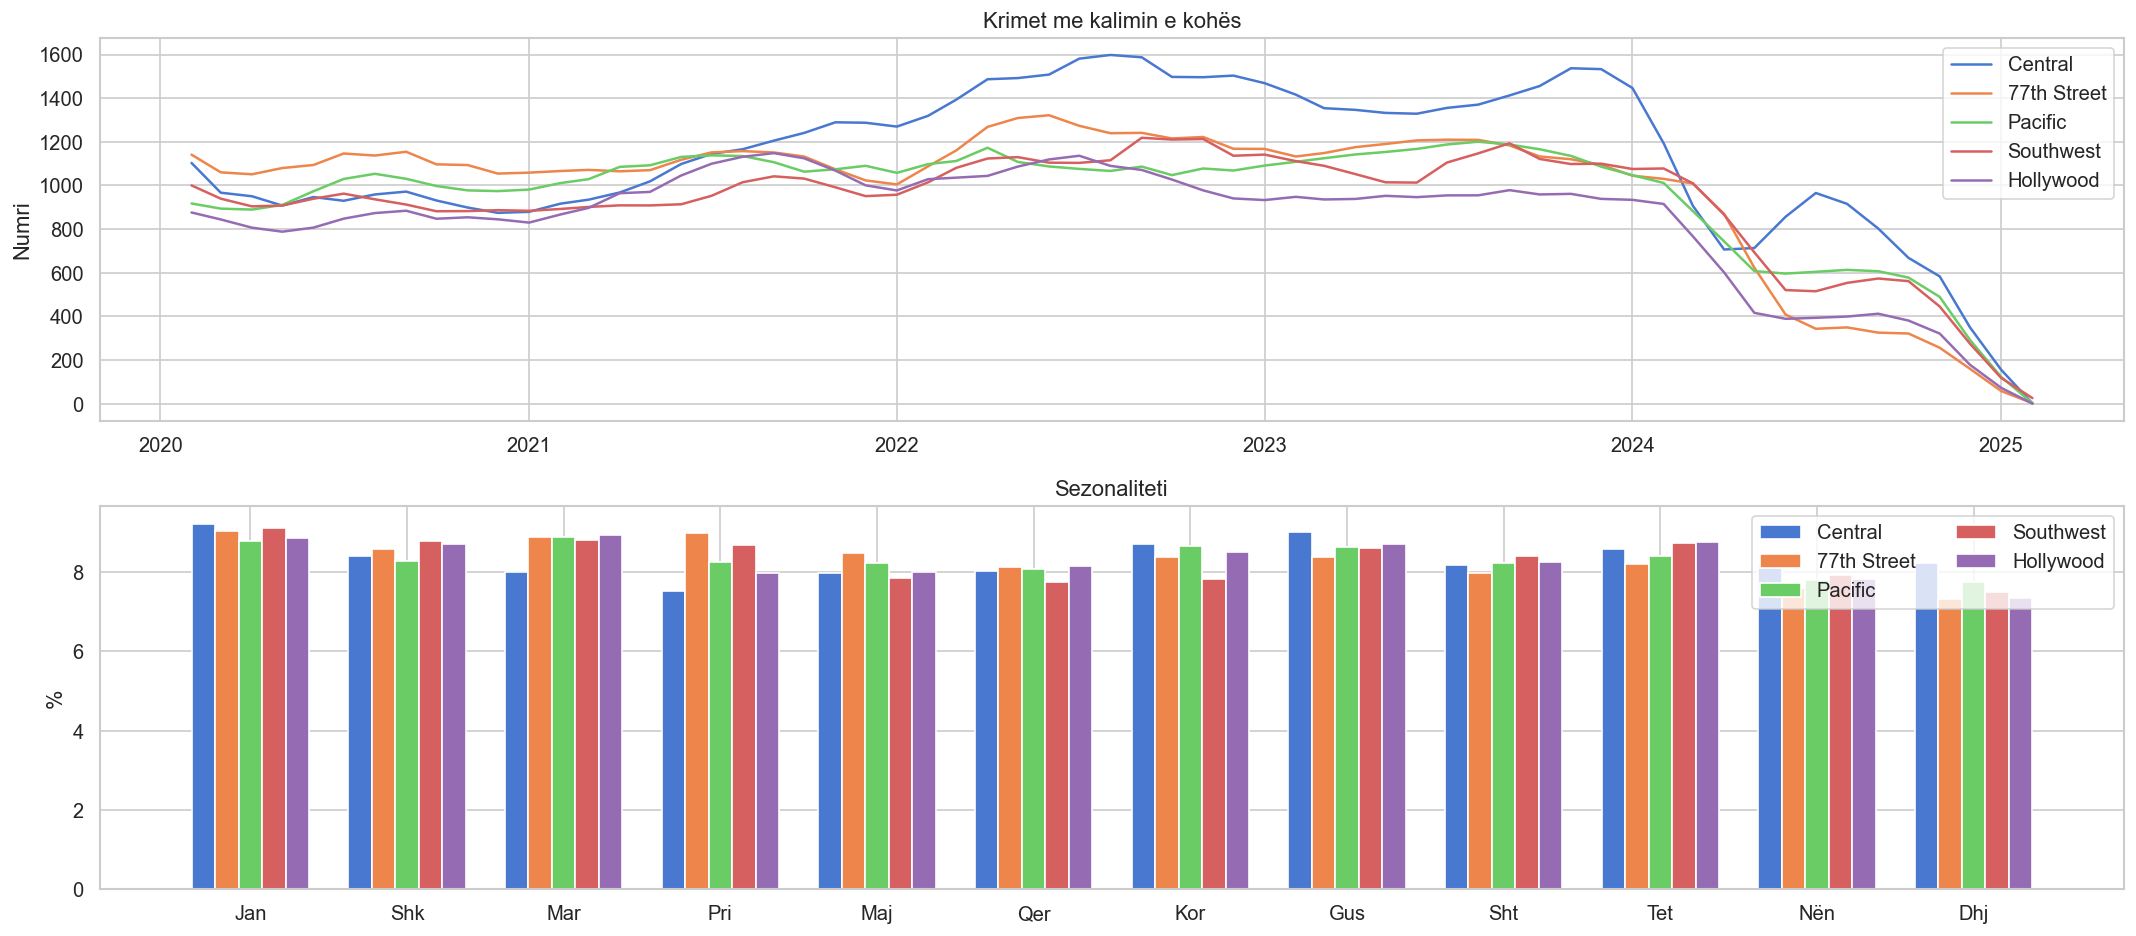

In [15]:
df_q5 = df.dropna(subset=["DATE OCC", "AREA NAME"]).copy()
df_q5["DATE OCC"] = pd.to_datetime(df_q5["DATE OCC"], errors="coerce")
df_q5["Part 1-2"] = pd.to_numeric(df_q5["Part 1-2"], errors="coerce")
df_q5 = df_q5.dropna(subset=["DATE OCC", "AREA NAME", "Part 1-2"])
df_q5["YearMonth"] = df_q5["DATE OCC"].dt.to_period("M")
df_q5["MonthNum"] = df_q5["DATE OCC"].dt.month

top5_areas = df_q5["AREA NAME"].value_counts().head(5).index.tolist()
df5 = df_q5[df_q5["AREA NAME"].isin(top5_areas)].copy()

monthly = df5.groupby(["YearMonth", "AREA NAME"]).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()
seasonal = df5.groupby(["MonthNum", "AREA NAME"]).size().unstack(fill_value=0).reindex(range(1, 13), fill_value=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 8))

for area in top5_areas:
    if area in monthly.columns:
        ax1.plot(monthly.index, monthly[area].rolling(3, center=True).mean(), label=area)

ax1.set_title("Krimet me kalimin e kohës")
ax1.set_ylabel("Numri")
ax1.legend()

months = ["Jan", "Shk", "Mar", "Pri", "Maj", "Qer", "Kor", "Gus", "Sht", "Tet", "Nën", "Dhj"]
x = np.arange(12)
w = 0.15

for i, area in enumerate(top5_areas):
    if area in seasonal.columns:
        vals = seasonal[area].values
        ax2.bar(x + i * w, vals / vals.sum() * 100, width=w, label=area)

ax2.set_xticks(x + w * 2)
ax2.set_xticklabels(months)
ax2.set_ylabel("%")
ax2.set_title("Sezonaliteti")
ax2.legend(ncol=2)

plt.tight_layout()
plt.show()

# 8: Ora e krimit dhe mosha e viktimës

**Pyetja:** Në cilat orë ndodhin më shpesh krimet për secilin lloj krimi dhe si ndryshon profili i viktimave sipas moshës dhe gjinisë?

<small>Grafiku është një scatter plot ku pikat janë të shpërndara me pak "jitter" horizontal për të formuar kolona dots për çdo orë. Ngjyrat ndajnë gjininë (M/F) dhe paraqesin vetëm 4 llojet kryesore të krimit (për lehtësi leximi). Këto pika ndihmojnë të dalloni nëse ka orë specifike me përqendrim të viktimave të caktuara sipas moshës. Shiko Pyetjen 7 në `more_interesting_graphs.ipynb` për variantet më të detajuara të këtij grafiku.</small>

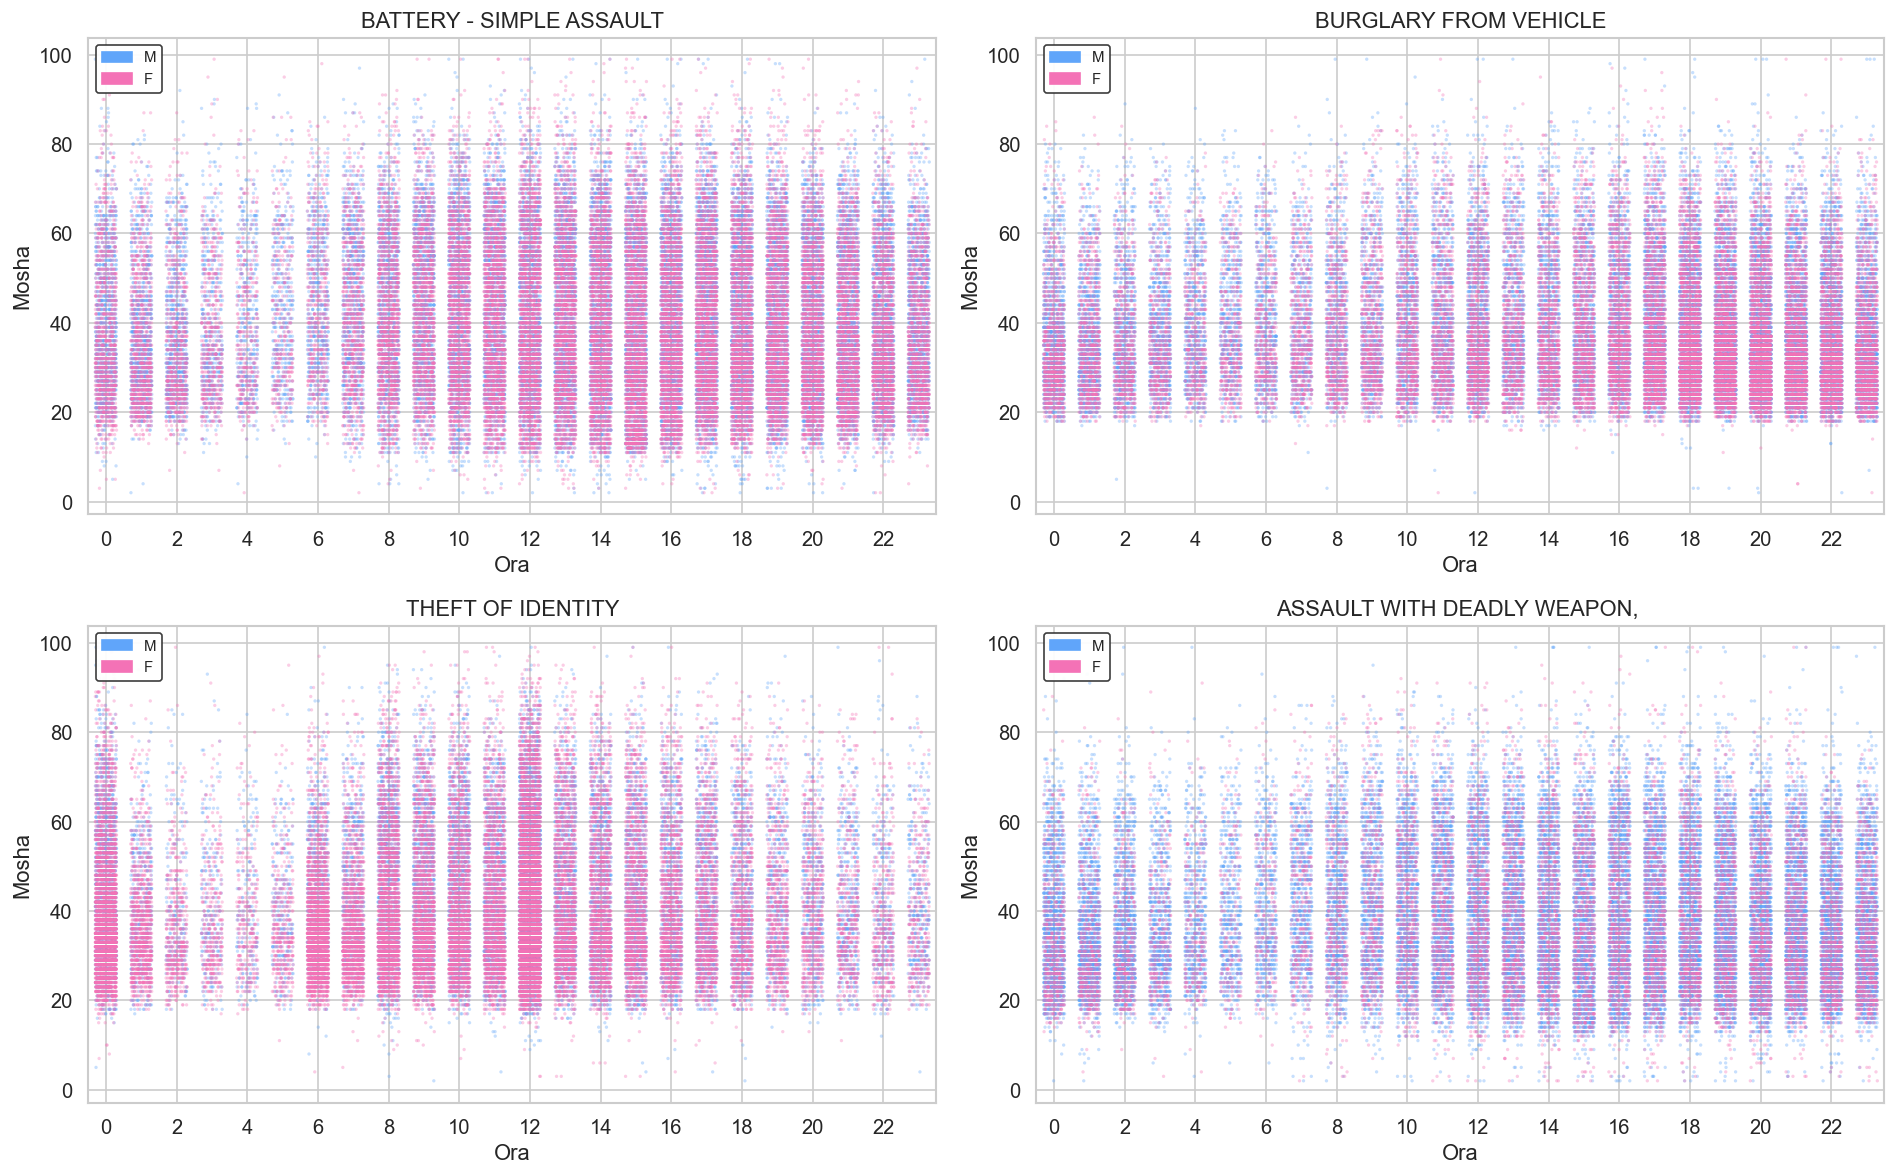

In [27]:
df_q6 = df.dropna(subset=["TIME OCC", "Vict Age", "Vict Sex", "Crm Cd Desc"]).copy()
df_q6["TIME OCC"] = pd.to_numeric(df_q6["TIME OCC"], errors="coerce")
df_q6["Vict Age"] = pd.to_numeric(df_q6["Vict Age"], errors="coerce")
df_q6 = df_q6.dropna(subset=["TIME OCC", "Vict Age"]) 
df_q6 = df_q6[df_q6["Vict Sex"].isin(["M", "F"]) ]
df_q6 = df_q6[df_q6["Vict Age"].between(1, 99)]
df_q6["Hour"] = (df_q6["TIME OCC"] // 100).astype(int).clip(0, 23)

top4 = df_q6["Crm Cd Desc"].value_counts().head(4).index.tolist()
short = {c: c[:28] for c in top4}
df4 = df_q6[df_q6["Crm Cd Desc"].isin(top4)].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, crime in enumerate(top4):
    ax = axes[idx // 2][idx % 2]
    sub = df4[df4["Crm Cd Desc"] == crime]

    for sex, color in [("M", "#60a5fa"), ("F", "#f472b6")]:
        piece = sub[sub["Vict Sex"] == sex]
        x_jitter = piece["Hour"] + np.random.uniform(-0.3, 0.3, len(piece))
        # reduced size and opacity so overlapping pink dots don't fully obscure blue
        ax.scatter(x_jitter, piece["Vict Age"], s=4, alpha=0.35, color=color, edgecolors="none", zorder=3)

    # use square color patches for a more visible legend and place at top-left
    handles = [mpatches.Patch(color="#60a5fa", label="M"), mpatches.Patch(color="#f472b6", label="F")]
    ax.legend(handles=handles, loc='upper left', frameon=True, framealpha=0.95, edgecolor="#333333", fontsize=9)

    ax.set_title(short[crime])
    ax.set_xlabel("Ora")
    ax.set_ylabel("Mosha")
    ax.set_xlim(-0.5, 23.5)
    ax.set_xticks(range(0,24,2))

plt.tight_layout()
plt.show()

---
## 10. Referencat

1. Los Angeles Police Department – Open Data Portal: https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8